# Chronos-2 기반 시계열 이상 탐지 (변수별, multivariate)

**아이디어**: 품질 변수와 POLYCOM 운전시간을 제외한 공정 변수 38개를 Chronos-2에 함께 입력하고, 과거 168시간으로 1시간 뒤를 예측합니다. 실제값이 예측 분포의 1~99% 구간 밖이면 이상으로 표시합니다.

기존 `chronos-bolt-small`(univariate, 변수 하나만 보고 그 변수를 예측)과 달리, **Chronos-2는 여러 변수를 함께 입력하면 서로의 패턴을 참고해서 예측**합니다 — 예: FEED량은 정상인데 그에 맞춰 같이 움직여야 할 온도가 안 움직이는 경우도 잡을 수 있습니다.

**사용 방법**
1. `CONFIG` 셀에서 `EXCEL_PATH`/`SHEET_NAME`이 맞는지 확인 (현재 2CM 운전 데이터로 설정됨)
2. 전처리는 GitHub Cement `review_v2`처럼 물리 한계 위반값만 NaN 처리하고, IQR/주변 중앙값 치환은 하지 않음
3. `QUICK_TEST_ROWS`로 소규모 확인 후 `None`으로 바꿔 전체 재실행
4. Full 파인튜닝은 시간순 70/15/15 분할 셀부터 순서대로 실행

**환경 확인 결과**: `amazon/chronos-2` 모델이 이 Mac에서 MPS(Apple GPU)로 정상 로드/추론되는 것 확인했습니다. Apache-2.0 라이선스 오픈소스 모델이라 비용 없이 사용 가능합니다.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import matplotlib.pyplot as plt

from chronos import BaseChronosPipeline

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 4)

# 기본 폰트(DejaVu Sans)에는 한글 글리프가 없어서 컬럼명의 한글이 깨져(□) 보이는 문제 방지.
# 맥/윈도우 둘 다에서 돌릴 수 있게, 실제 설치된 폰트 목록에서 있는 것만 골라서 씀
# (없는 폰트를 그냥 지정하면 matplotlib이 기본 폰트로 조용히 대체해버려서 한글이 깨짐).
import matplotlib.font_manager as fm

_korean_font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]
_available_fonts = {f.name for f in fm.fontManager.ttflist}
_korean_font = next((f for f in _korean_font_candidates if f in _available_fonts), None)
if _korean_font:
    plt.rcParams["font.family"] = _korean_font
    print(f"한글 폰트 사용: {_korean_font}")
else:
    print("경고: 한글 폰트(AppleGothic/맑은 고딕/나눔고딕)를 못 찾았습니다 -- 그래프의 한글이 깨질 수 있습니다.")
plt.rcParams["axes.unicode_minus"] = False  # 일부 한글 폰트엔 유니코드 마이너스(−) 글리프가 없어서 꺼줌


한글 폰트 사용: AppleGothic


In [2]:
# ===================== CONFIG: GitHub Cement review_v2 방식 =====================
from pathlib import Path
import importlib
import cement_chronos_review_v2 as _cement_review_v2
importlib.invalidate_caches()
_cement_review_v2 = importlib.reload(_cement_review_v2)

from cement_chronos_review_v2 import (
    DOWNTIME_COL, PROTOCOL_VERSION, QUALITY_COLS,
    apply_iqr_thresholds, chronological_split, equipment_frame, file_sha256,
    fit_iqr_thresholds,
    load_preprocessed_equipment, loss_history_from_callback,
    make_loss_history_callback, rolling_forecast_multivariate as rolling_forecast_review_v2,
    runtime_versions, to_chronos_inputs, validation_windows,
)

EXCEL_PATH = "운전데이터_통합_2CM_3CM_4CM.xlsx"
SHEET_NAME = "운전데이터_통합"
HEADER_ROW = 0
EQUIPMENT_IDS = ["2CM", "3CM", "4CM"]

# 예측 대상에서 제외하는 건 운전시간/품질 2개뿐이다 (관측률과 무관하게 나머지는 전부 예측).
#   POLYCOM 운전시간: 정지 판정/past covariate로만 사용, 예측 대상 아님
#   기타 품질 BLAINE, 44마이크론R: 품질 지표, 예측 대상 아님
#   기타 분쇄조제: 제어변수라서 다시 예측 대상에 포함시킴 (제어변수+모니터링변수를 다 예측하기로 함)
#   기타 품종/비고: 범주형이라 load_preprocessed_equipment 안에서 이미 드롭되어 target_cols에
#   아예 안 들어옴 -- 그래서 아래 목록엔 명시적으로 안 넣어도 됨.
PREDICT_EXCLUDE_COLS = [DOWNTIME_COL, *QUALITY_COLS]
GLITCH_VARIANTS = []                 # 기존 중앙값 글리치 분기는 실행하지 않음

CONTEXT_LENGTH = 168                # 과거 1주일
PREDICTION_LENGTH = 1               # 요청대로 1시간 뒤 하나만 예측
STRIDE = 1
assert PREDICTION_LENGTH == 1, "현재 review_v2 파이프라인은 prediction_length=1로 고정합니다."

ANOMALY_QUANTILE_LOW = 0.01
ANOMALY_QUANTILE_HIGH = 0.99
SEVERITY_EPS = 1e-3

# IQR은 학습 데이터에만 적용하는 규칙이므로 학습이 없는 일반(Zero-shot) Chronos에는
# 별도의 IQR 적용 버전을 만들지 않습니다. Tukey 1.5×IQR 비교는 아래 Full 파인튜닝 셀에서
# 시간순 Train 70%에만 적용해 수행합니다.
IQR_VARIANTS = [False]
IQR_MULTIPLIER = 1.5

PREPROCESSED_DIR = Path("data/processed")
PREPROCESSED_CSV = PREPROCESSED_DIR / "process_timeseries_review_v2.csv"

MODEL_ID = "amazon/chronos-2"
BATCH_WINDOWS = 128
QUICK_TEST_ROWS = None              # None이면 전체 기간

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Selected device: {DEVICE}, protocol={PROTOCOL_VERSION}, prediction_length={PREDICTION_LENGTH}")


Selected device: mps, protocol=review_v2_process_pred1, prediction_length=1


In [3]:
# ===================== 데이터 로드: GitHub review_v2 전처리 =====================
def load_data(equipment_id):
    """물리 기준 마스킹 -> 내수 품종 필터 -> 숫자 변환 -> 1시간 grid 재색인.
    관측률과 무관하게, PREDICT_EXCLUDE_COLS에 명시된 것만 예측 대상에서 뺀다(데이터엔 남겨둠).
    운전시간/품질은 모듈(load_preprocessed_equipment)에서 이미 target_cols 밖으로 빠져있어서
    아래 필터는 사실상 '기타 분쇄조제'에만 적용됨."""
    data, time_index, target_cols, cleaning_audit, stats = load_preprocessed_equipment(
        EXCEL_PATH, SHEET_NAME, equipment_id, header_row=HEADER_ROW,
    )
    target_cols = [c for c in target_cols if c not in PREDICT_EXCLUDE_COLS]
    stats["n_targets"] = len(target_cols)
    return data, time_index, target_cols, cleaning_audit, stats


In [4]:
# ===================== 이상치 제거 원칙 =====================
# 기존 ±3시간 중앙값/Hampel 유사 글리치 탐지는 사용하지 않는다.
# GitHub Cement_code_fin의 canonical 방식처럼 명백한 물리/설비 한계 위반값만 NaN 처리한다.
# 따라서 값을 주변 중앙값으로 대체하지 않으며, 통계적 IQR 제거도 수행하지 않는다.
print("전처리: fixed physical limits -> NaN, IQR/median replacement 없음")


전처리: fixed physical limits -> NaN, IQR/median replacement 없음


In [5]:
# ===================== Chronos 모델 로드 =====================
pipeline = BaseChronosPipeline.from_pretrained(
    MODEL_ID,
    device_map=DEVICE,
    torch_dtype=torch.float32,
)
print(f"Loaded {MODEL_ID} on {DEVICE}")


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loaded amazon/chronos-2 on mps


In [6]:
# ===================== 예측 정확도 계산 함수 =====================
# gap/down/warmup 시점은 빼고 계산하고, "직전 시간값"이 idx 기준으로 진짜 1시간 전인 경우만
# 스코어링 대상에 포함합니다 (안 그러면 시간갭 바로 다음 시점을 마치 정상 연속 구간처럼 계산하는
# 오류가 생김 -- naive_pred는 이 유효성 체크에만 쓰고 지표 자체(MAE)는 안 냄).
# MAPE는 실제값이 0에 가까우면(예: 0~1 사이를 오가는 변수) 분모가 0에 가까워져서 터무니없이
# 커지는 문제가 있어서, |실제값| <= mape_min_abs인 시점은 MAPE 계산에서만 제외합니다
# (mape_n/mape_skipped로 몇 개를 뺐는지 남겨둠 -- MAPE가 이상하게 크게 나오는 변수는 이 값도 같이 확인).
# Accuracy(%) = 100 - MAPE(%) -- |측정값-참값|/참값 x 100(%)의 평균을 100에서 뺀 값으로,
# MAPE가 0에 가까울수록(=오차가 작을수록) Accuracy는 100에 가까워짐 (1세대 ANN 보고서 관례).
# 평가지표는 R²/RMSE/MAPE/Accuracy/Coverage 5개만 씀 -- MAE는 안 씀.

def compute_accuracy_summary(results_df, mape_min_abs=1e-6):
    rows = []
    for col, sub in results_df.groupby("variable"):
        sort_column = "idx" if "idx" in sub.columns else "timestamp"
        sub = sub.sort_values(sort_column).reset_index(drop=True)
        actual = sub["actual"].to_numpy()
        pred = sub["pred_median"].to_numpy()
        scored = sub["excluded_reason"].isna().to_numpy()

        naive_pred = np.roll(actual, 1)
        naive_pred[0] = np.nan
        valid = scored & ~np.isnan(naive_pred)
        n_scored = int(valid.sum())
        if n_scored < 2:
            continue

        actual_v = actual[valid]
        err = actual_v - pred[valid]
        rmse = np.sqrt(np.mean(err ** 2))

        mape_mask = np.abs(actual_v) > mape_min_abs
        mape_n = int(mape_mask.sum())
        mape_skipped = int((~mape_mask).sum())
        mape = np.mean(np.abs(err[mape_mask] / actual_v[mape_mask])) * 100 if mape_n > 0 else np.nan
        accuracy = 100 - mape if not np.isnan(mape) else np.nan

        low = sub["pred_low"].to_numpy()[valid]
        high = sub["pred_high"].to_numpy()[valid]
        coverage = ((actual_v >= low) & (actual_v <= high)).mean() * 100

        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((actual_v - actual_v.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        rows.append(dict(
            variable=col, label=col.replace("\n", " "),
            rmse=rmse, mape=mape, accuracy=accuracy, mape_n=mape_n, mape_skipped=mape_skipped,
            r2=r2, coverage=coverage, n_scored=n_scored,
        ))
    return pd.DataFrame(rows)


In [7]:
# ===================== GitHub review_v2 방식 메인 파이프라인 =====================
# 1) 고정 물리 기준 위반값만 NaN 처리
# 2) 내수 품종만 유지, 실제 시간 갭은 1시간 grid의 NaN으로 유지
# 3) 품질 변수와 POLYCOM 운전시간은 예측 대상에서 제외
# 4) 운전시간은 past covariate 및 정지 판정에만 사용
# 5) Zero-shot은 학습 단계가 없으므로 IQR 적용/미적용으로 나누지 않음
# 6) Tukey IQR 비교는 아래 Full 파인튜닝에서만 수행


_prepared_cache = {}
_processed_frames = []
for equipment_id in EQUIPMENT_IDS:
    data_full, time_full, variable_cols, cleaning_audit, prep_stats = load_data(equipment_id)
    _prepared_cache[equipment_id] = (data_full, time_full, variable_cols, cleaning_audit, prep_stats)
    _processed_frames.append(equipment_frame(equipment_id, data_full, time_full, variable_cols))
    print(f"[{equipment_id}] {prep_stats}")

PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
processed_all = pd.concat(_processed_frames, ignore_index=True)
processed_all.to_csv(PREPROCESSED_CSV, index=False, encoding="utf-8-sig")
print(f"전처리 데이터 저장: {PREPROCESSED_CSV} ({len(processed_all):,}행)")

try:
    if any(r.get("protocol") != PROTOCOL_VERSION for r in equipment_results.values()):
        equipment_results = {}
except NameError:
    equipment_results = {}

for use_iqr_trim in IQR_VARIANTS:
    for equipment_id in EQUIPMENT_IDS:
        run_key = f"{equipment_id}__{'review_v2_iqr' if use_iqr_trim else 'review_v2'}"
        if run_key in equipment_results:
            print(f"{run_key}: 이미 처리됨 -> 건너뜀")
            continue

        data, time_index, variable_cols, cleaning_audit, prep_stats = _prepared_cache[equipment_id]
        if QUICK_TEST_ROWS is not None:
            data = data.tail(QUICK_TEST_ROWS).reset_index(drop=True)
            time_index = time_index.tail(QUICK_TEST_ROWS).reset_index(drop=True)

        data_raw = data.copy()
        n_iqr_trimmed = 0
        iqr_thresholds = pd.DataFrame()
        if use_iqr_trim:
            frame = equipment_frame(equipment_id, data, time_index, variable_cols)
            train_frame, _, _ = chronological_split(frame)
            iqr_thresholds = fit_iqr_thresholds(
                train_frame, variable_cols, multiplier=IQR_MULTIPLIER,
            )
            train_iqr, train_mask_summary = apply_iqr_thresholds(
                train_frame, iqr_thresholds, variable_cols,
            )
            data = data.copy()
            data.loc[:len(train_iqr) - 1, variable_cols] = train_iqr[variable_cols].to_numpy()
            n_iqr_trimmed = int(train_mask_summary["masked"].sum())

        is_gap_row = data[variable_cols].isna().all(axis=1).to_numpy()
        is_down = data[DOWNTIME_COL].eq(0).fillna(False).to_numpy()
        is_warmup = np.zeros(len(data), dtype=bool)  # review_v2에서는 임의의 재가동 제외시간을 두지 않음
        score_eligible = ~is_gap_row & ~is_down
        variable_scale = data.loc[score_eligible, variable_cols].std().fillna(0.0).to_numpy()

        all_results = rolling_forecast_review_v2(
            pipeline, data, variable_cols, variable_scale, is_down, actual_data=data_raw,
            context_length=CONTEXT_LENGTH, prediction_length=PREDICTION_LENGTH,
            stride=STRIDE, batch_windows=BATCH_WINDOWS,
            quantile_low=ANOMALY_QUANTILE_LOW, quantile_high=ANOMALY_QUANTILE_HIGH,
            severity_eps=SEVERITY_EPS,
        )
        all_results["timestamp"] = [time_index[i] for i in all_results["idx"]]
        results = {col: sub.reset_index(drop=True) for col, sub in all_results.groupby("variable")}
        scored = all_results[all_results["excluded_reason"].isna()]
        summary = (
            scored.groupby("variable")
            .agg(n_points=("is_anomaly", "size"), n_anomalies=("is_anomaly", "sum"), max_severity=("severity", "max"))
            .assign(anomaly_rate=lambda frame: frame["n_anomalies"] / frame["n_points"])
            .sort_values("n_anomalies", ascending=False)
        )
        accuracy_summary = compute_accuracy_summary(all_results)
        values = data[variable_cols].to_numpy(dtype=np.float32)

        equipment_results[run_key] = dict(
            protocol=PROTOCOL_VERSION, equipment_id=equipment_id, physical_cleaned=True,
            iqr_trimmed=use_iqr_trim, clean_data_glitches=True, data=data, data_raw=data_raw,
            time_index=time_index, variable_cols=variable_cols, is_down=is_down, is_warmup=is_warmup,
            variable_scale=variable_scale, values=values, raw_values=values.copy(),
            glitch_records=[], physical_cleaning_count=len(cleaning_audit),
            iqr_trimmed_count=n_iqr_trimmed, iqr_thresholds=iqr_thresholds, preprocessing_stats=prep_stats,
            all_results=all_results, results=results, summary=summary, accuracy_summary=accuracy_summary,
        )
        print(f"[{run_key}] targets={len(variable_cols)}, IQR추가마스킹={n_iqr_trimmed}, scored={len(scored):,}, "
              f"anomalies={int(scored['is_anomaly'].sum()):,} ({scored['is_anomaly'].mean()*100:.2f}%)")

print(f"완료된 review_v2 run: {list(equipment_results.keys())}")


[2CM] {'equipment_id': '2CM', 'observed_rows': 39842, 'hourly_rows': 51209, 'inserted_gap_rows': 11367, 'bad_timestamp_rows': 0, 'duplicate_timestamp_rows': 0, 'product_rows_dropped': 10, 'physical_values_masked': 275, 'n_targets': 38}
[3CM] {'equipment_id': '3CM', 'observed_rows': 40050, 'hourly_rows': 51209, 'inserted_gap_rows': 11159, 'bad_timestamp_rows': 0, 'duplicate_timestamp_rows': 0, 'product_rows_dropped': 19, 'physical_values_masked': 287, 'n_targets': 38}
[4CM] {'equipment_id': '4CM', 'observed_rows': 39387, 'hourly_rows': 51209, 'inserted_gap_rows': 11822, 'bad_timestamp_rows': 0, 'duplicate_timestamp_rows': 0, 'product_rows_dropped': 32, 'physical_values_masked': 405, 'n_targets': 38}
전처리 데이터 저장: data/processed/process_timeseries_review_v2.csv (153,627행)
[2CM__review_v2] targets=38, IQR추가마스킹=0, scored=1,249,534, anomalies=17,622 (1.41%)
[3CM__review_v2] targets=38, IQR추가마스킹=0, scored=1,254,296, anomalies=18,545 (1.48%)
[4CM__review_v2] targets=38, IQR추가마스킹=0, scored=1,264

                     설비  물리기준정리  IQR추가정리  변수수   스코어링대상  이상탐지수   이상비율  \
run                                                                    
2CM__review_v2      2CM    True    False   38  1249534  17622  1.410   
3CM__review_v2      3CM    True    False   38  1254296  18545  1.479   
4CM__review_v2      4CM    True    False   38  1264506  18906  1.495   
2CM__review_v2_iqr  2CM    True     True   38  1060775  11689  1.102   
3CM__review_v2_iqr  3CM    True     True   38  1054748  12019  1.140   
4CM__review_v2_iqr  4CM    True     True   38  1068281  12379  1.159   

                    물리기준마스킹건수  IQR마스킹건수  평균_R2  중앙값_R2  평균_coverage  평균_MAPE  \
run                                                                            
2CM__review_v2            275         0  0.144   0.188       98.668    4.643   
3CM__review_v2            287         0  0.065   0.062       98.627    5.574   
4CM__review_v2            405         0  0.109   0.176       98.626    5.682   
2CM__review_v2_iqr     

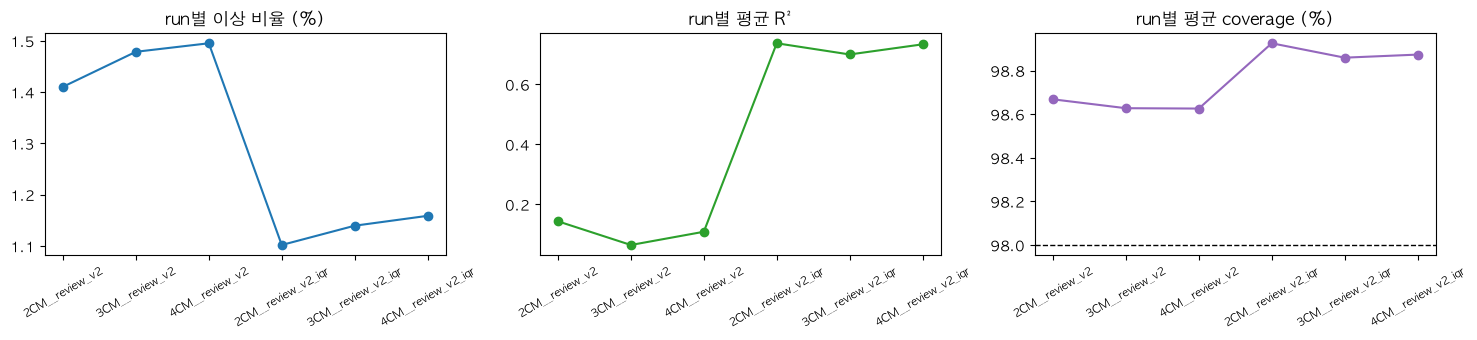

,설비,물리기준정리,IQR추가정리,변수수,스코어링대상,이상탐지수,이상비율,물리기준마스킹건수,IQR마스킹건수,평균_R2,중앙값_R2,평균_coverage,평균_MAPE,평균_Accuracy
run,,,,,,,,,,,,,,
2CM__review_v2,2CM,True,False,38,1249534,17622,1.410286,275,0,0.143614,0.187694,98.667976,4.643120,95.356880
3CM__review_v2,3CM,True,False,38,1254296,18545,1.478519,287,0,0.064717,0.061863,98.627272,5.574101,94.425899
4CM__review_v2,4CM,True,False,38,1264506,18906,1.495129,405,0,0.108789,0.175808,98.625587,5.681897,94.318103
2CM__review_v2_iqr,2CM,True,True,38,1060775,11689,1.101930,275,189608,0.736844,0.866747,98.925003,2.236871,97.763129
3CM__review_v2_iqr,3CM,True,True,38,1054748,12019,1.139514,287,200812,0.699546,0.846571,98.858975,2.507394,97.492606
4CM__review_v2_iqr,4CM,True,True,38,1068281,12379,1.158778,405,197243,0.733318,0.858390,98.873086,2.578927,97.421073


In [8]:
# ===================== 설비별 review_v2 결과 비교 요약 =====================
# R² / coverage / MAPE / Accuracy 기준으로 비교 (MAE는 안 씀, RMSE는 이상치 하나에도 크게 튀어서 제외)
compare_rows = []
for run_key, r in equipment_results.items():
    scored = r["all_results"][r["all_results"]["excluded_reason"].isna()]
    acc = compute_accuracy_summary(r["all_results"])
    compare_rows.append(dict(
        run=run_key,
        설비=r["equipment_id"],
        물리기준정리=r.get("physical_cleaned", False),
        IQR추가정리=r.get("iqr_trimmed", False),
        변수수=len(r["variable_cols"]),
        스코어링대상=len(scored),
        이상탐지수=int(scored["is_anomaly"].sum()),
        이상비율=scored["is_anomaly"].mean() * 100,
        물리기준마스킹건수=r.get("physical_cleaning_count", 0),
        IQR마스킹건수=r.get("iqr_trimmed_count", 0),
        평균_R2=acc["r2"].mean(),
        중앙값_R2=acc["r2"].median(),
        평균_coverage=acc["coverage"].mean(),
        평균_MAPE=acc["mape"].mean(),
        평균_Accuracy=acc["accuracy"].mean(),
    ))
equipment_comparison = pd.DataFrame(compare_rows).set_index("run")
print(equipment_comparison.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].plot(equipment_comparison.index, equipment_comparison["이상비율"], marker="o", color="tab:blue", linewidth=1.5)
axes[0].set_title("run별 이상 비율 (%)")
axes[1].plot(equipment_comparison.index, equipment_comparison["평균_R2"], marker="o", color="tab:green", linewidth=1.5)
axes[1].set_title("run별 평균 R²")
axes[2].plot(equipment_comparison.index, equipment_comparison["평균_coverage"], marker="o", color="tab:purple", linewidth=1.5)
axes[2].axhline((ANOMALY_QUANTILE_HIGH - ANOMALY_QUANTILE_LOW) * 100, color="black", linestyle="--", linewidth=1)
axes[2].set_title("run별 평균 coverage (%)")
for ax in axes:
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
plt.tight_layout()
plt.show()

equipment_comparison


In [9]:
# ===================== 전체 run(설비 x 글리치처리 여부) CSV 한 번에 저장 =====================
# CURRENT_RUN을 매번 손으로 바꿔가며 "결과 저장"/"예측값 wide 저장" 셀을 반복하는 대신,
# equipment_results에 있는 모든 run을 한 번에 순회하면서 long/wide 두 형식 다 저장합니다.
cols_to_save = ["variable", "timestamp", "actual", "pred_median", "pred_low", "pred_high",
                "error", "severity", "is_anomaly", "excluded_reason"]

for _run_key, _r in equipment_results.items():
    _all_results = _r["all_results"]

    # long format
    _export_df = _all_results[cols_to_save].copy()
    _export_df["variable"] = _export_df["variable"].str.replace("\n", " ")
    _long_path = f"chronos_anomaly_results_{_run_key}.csv"
    _export_df.to_csv(_long_path, index=False, encoding="utf-8-sig")

    # wide format (원본 엑셀 형식, 예측 중앙값 기준)
    _wide = _all_results.copy()
    _wide["variable"] = _wide["variable"].str.replace("\n", " ")
    _wide = _wide.pivot(index="timestamp", columns="variable", values="pred_median").reset_index()
    _wide.insert(0, "ID", _r["equipment_id"])
    _wide.insert(1, "근무일자", _wide["timestamp"].dt.strftime("%Y-%m-%d"))
    _wide.insert(2, "근무시간", _wide["timestamp"].dt.hour)
    _wide = _wide.drop(columns=["timestamp"])
    _wide_path = f"chronos_predicted_원본형식_{_run_key}.csv"
    _wide.to_csv(_wide_path, index=False, encoding="utf-8-sig")

    print(f"저장 완료: {_long_path} ({len(_export_df)}행), {_wide_path} ({_wide.shape[0]}행 x {_wide.shape[1]}컬럼)")

print(f"\n총 {len(equipment_results)}개 run 저장 완료: {list(equipment_results.keys())}")


저장 완료: chronos_anomaly_results_2CM__review_v2.csv (1939558행), chronos_predicted_원본형식_2CM__review_v2.csv (51041행 x 41컬럼)
저장 완료: chronos_anomaly_results_3CM__review_v2.csv (1939558행), chronos_predicted_원본형식_3CM__review_v2.csv (51041행 x 41컬럼)
저장 완료: chronos_anomaly_results_4CM__review_v2.csv (1939558행), chronos_predicted_원본형식_4CM__review_v2.csv (51041행 x 41컬럼)
저장 완료: chronos_anomaly_results_2CM__review_v2_iqr.csv (1939558행), chronos_predicted_원본형식_2CM__review_v2_iqr.csv (51041행 x 41컬럼)
저장 완료: chronos_anomaly_results_3CM__review_v2_iqr.csv (1939558행), chronos_predicted_원본형식_3CM__review_v2_iqr.csv (51041행 x 41컬럼)
저장 완료: chronos_anomaly_results_4CM__review_v2_iqr.csv (1939558행), chronos_predicted_원본형식_4CM__review_v2_iqr.csv (51041행 x 41컬럼)

총 6개 run 저장 완료: ['2CM__review_v2', '3CM__review_v2', '4CM__review_v2', '2CM__review_v2_iqr', '3CM__review_v2_iqr', '4CM__review_v2_iqr']


In [10]:
# ===================== 상세 분석할 review_v2 run 선택 =====================
# CURRENT_RUN의 설비명만 바꾸면 2CM/3CM/4CM 결과를 전환할 수 있습니다.
# accuracy_summary는 캐시된 값을 안 쓰고 매번 새로 계산합니다 (Chronos 재추론 없이 순수 집계라
# 빠르고, compute_accuracy_summary 함수를 수정했을 때 캐시가 옛날 버전이라 안 바뀌는 문제를 방지).
CURRENT_RUN = "2CM__review_v2"

_r = equipment_results[CURRENT_RUN]
CURRENT_EQUIPMENT = _r["equipment_id"]  # 원래 설비명만 (파일명/ID 컬럼용)
data, data_raw, variable_cols = _r["data"], _r["data_raw"], _r["variable_cols"]
variable_scale = _r["variable_scale"]
all_results, results = _r["all_results"], _r["results"]
summary = _r["summary"]
accuracy_summary = compute_accuracy_summary(all_results)

print(f"현재 상세 보기: {CURRENT_RUN} (설비={CURRENT_EQUIPMENT}, "
      f"물리 기준 NaN 처리 {_r['physical_cleaning_count']}건)")
summary


현재 상세 보기: 2CM__review_v2 (설비=2CM, 물리 기준 NaN 처리 275건)


,n_points,n_anomalies,max_severity,anomaly_rate
variable,,,,
POLYCOM\nW/F FEED\nTOTAL,36417,966,10.974980,0.026526
POLYCOM\nW/F FEED\nSLAG,36368,953,6.221090,0.026204
POLYCOM\nW/F FEED\n크링커,36417,941,11.895010,0.025840
POLYCOM\nW/F FEED\n석고,36415,867,9.566851,0.023809
정분B/E\n1단\n부하,35410,679,66.593706,0.019175
정분B/E\n2단\n부하,35410,664,62.461996,0.018752
MILL\nFEED\n순환량,35411,649,44.564484,0.018328
POLYCOM\nW/F FEED\nF/A,31053,629,37.288917,0.020256
MILL\nFEED\n조분량,35408,618,49.549953,0.017454


In [1]:
# ===================== 예측 정확도 시각화 =====================
# R² / RMSE / coverage / MAPE / Accuracy 다섯 가지를 변수별로 꺾은선 그래프로 봅니다
# (변수는 R² 높은 순 정렬).
# - R²: 변수마다 스케일이 달라서 변수 간 비교에 제일 적합 (0.5 이상=잘 맞음, 음수=평균 찍는 것보다 못함).
# - RMSE: 큰 오차에 더 민감한 실제 단위 오차. 변수마다 단위/크기가 달라 절댓값의 변수 간 비교는 주의.
# - coverage: 예측 구간(1~99%)에 실제값이 들어온 비율 -- 이상탐지 판정 기준 자체가 잘 맞는지 확인
# - MAPE: 상대오차(%). 실제값이 0 근처인 변수는 분모가 작아져서 값이 커질 수 있음
#   (accuracy_summary의 mape_skipped로 몇 개 뺐는지 확인 가능).
# - Accuracy: 100 - MAPE(%), 높을수록 좋음.
# RMSE도 표시하되 극단치 하나에 완전히 흔들릴 수 있으므로(조분량 사례처럼 비정상적으로 큰 값),
# 아래 기준으로 극단적인 RMSE 변수는 메인 그래프에서 제외하고 별도 표로 보여줍니다.
#
# RMSE가 전체 중앙값 대비 압도적으로 큰 변수는 (다른 그래프에서도) 따로 뺌 -- 그 변수 하나가
# 축을 다 눌러버려서 나머지 변수들끼리 비교가 안 되는 문제가 있었음. 이런 변수는 메인 그래프에서
# 빼고 별도 표로 보여줌 (accuracy_summary는 위 "상세 분석할 설비 선택" 셀에서 이미 계산되어 있음).

def plot_accuracy_summary(acc=None, outlier_rmse_multiplier=20, title_prefix=""):
    # acc=None이면 호출 시점의 최신 accuracy_summary를 씀 (함수 정의 시점 값으로
    # 고정되면 계산 함수를 고쳐도 '설비 선택' 셀을 다시 안 돌리면 옛날 값이 남는 문제가 있었음)
    acc = accuracy_summary if acc is None else acc
    target_coverage = (ANOMALY_QUANTILE_HIGH - ANOMALY_QUANTILE_LOW) * 100
    acc = acc.dropna(subset=["r2"])

    median_rmse = acc["rmse"].median()
    is_extreme = acc["rmse"] > median_rmse * outlier_rmse_multiplier
    acc_extreme = acc[is_extreme]
    acc_main = acc[~is_extreme]

    acc_sorted = acc_main.sort_values("r2", ascending=False).reset_index(drop=True)
    x = range(len(acc_sorted))

    fig, axes = plt.subplots(5, 1, figsize=(max(10, len(acc_sorted) * 0.35), 17), sharex=True)
    prefix = f"{title_prefix} — " if title_prefix else ""

    ax = axes[0]
    ax.plot(x, acc_sorted["r2"], marker="o", markersize=4, color="tab:green", linewidth=1.2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(prefix + "R² (설명력) -- 0.5 이상=잘 맞음, 음수=평균 찍는 것보다 못함")
    ax.tick_params(axis="y", labelsize=8)

    ax = axes[1]
    ax.plot(x, acc_sorted["rmse"], marker="o", markersize=4, color="tab:red", linewidth=1.2)
    ax.set_title(prefix + "RMSE (실제 단위, 낮을수록 좋음; 변수별 단위 차이 주의)")
    ax.tick_params(axis="y", labelsize=8)

    ax = axes[2]
    ax.plot(x, acc_sorted["coverage"], marker="o", markersize=4, color="tab:purple", linewidth=1.2)
    ax.axhline(target_coverage, color="black", linewidth=1, linestyle="--")
    ax.set_title(prefix + f"예측구간 커버리지 % (점선={target_coverage:.0f}% 이상적)")
    ax.tick_params(axis="y", labelsize=8)

    ax = axes[3]
    ax.plot(x, acc_sorted["mape"], marker="o", markersize=4, color="tab:orange", linewidth=1.2)
    ax.set_title(prefix + "MAPE (%)")
    ax.tick_params(axis="y", labelsize=8)

    ax = axes[4]
    ax.plot(x, acc_sorted["accuracy"], marker="o", markersize=4, color="tab:blue", linewidth=1.2)
    ax.axhline(100, color="black", linewidth=0.8)
    ax.set_title(prefix + "Accuracy (%) = 100 - MAPE")
    ax.tick_params(axis="y", labelsize=8)

    # sharex=True를 쓰면 매트플롯립이 기본적으로 맨 아래 그래프에만 x축 라벨(변수명)을 남기고
    # 위쪽은 다 지워버림 -> 매번 맨 아래까지 스크롤해서 봐야 하는 게 불편해서, 모든 패널에
    # 변수명이 다 보이게 강제로 다시 켜줌.
    for ax in axes:
        ax.set_xticks(list(x))
        ax.set_xticklabels(acc_sorted["label"], rotation=90, fontsize=7)
        ax.tick_params(axis="x", labelbottom=True)

    plt.tight_layout()
    plt.show()

    print(f"전체 평균(아래 극단치 제외, {len(acc_main)}개 기준): "
          f"R²={acc_main['r2'].mean():.3f}(중앙값 {acc_main['r2'].median():.3f}), "
          f"RMSE={acc_main['rmse'].mean():.3f}, "
          f"coverage={acc_main['coverage'].mean():.2f}%(목표 {target_coverage:.0f}%), "
          f"MAPE={acc_main['mape'].mean():.2f}%, Accuracy={acc_main['accuracy'].mean():.2f}%")
    print(f"R² >= 0.5인 변수: {(acc_main['r2'] >= 0.5).sum()}/{len(acc_main)}")

    if len(acc_extreme):
        print(f"\n[그래프에서 제외한 극단치 변수 {len(acc_extreme)}개] "
              f"RMSE가 전체 중앙값({median_rmse:.2f})의 {outlier_rmse_multiplier}배 초과 "
              f"-- 데이터 자체에 물리적으로 불가능한 극단값이 섞여있을 가능성이 높음, 별도 확인 필요:")
        display(acc_extreme[["label", "r2", "rmse", "coverage", "mape", "accuracy", "n_scored"]])

    print("\n변수별 상세 (R² 높은 순, 극단치 제외):")
    display(acc_sorted[["label", "r2", "rmse", "coverage", "mape", "accuracy", "n_scored"]])


plot_accuracy_summary(title_prefix=f"일반 Chronos · {CURRENT_RUN}")


NameError: name 'CURRENT_RUN' is not defined

[2CM] 변수 38개 자기상관(lag 0~336h) 계산 완료


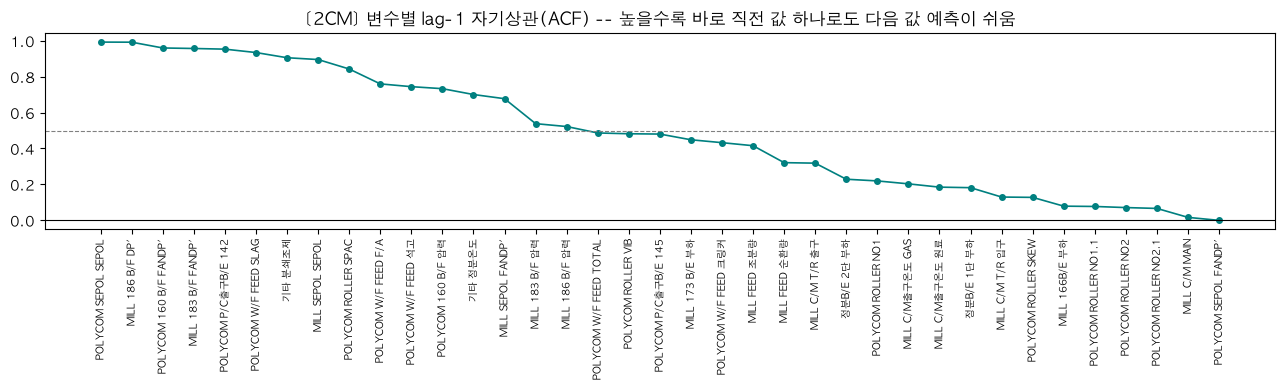


R² 높은 변수(예측 잘 됨) vs 낮은 변수(예측 잘 안 됨)의 자기상관 구조 비교:


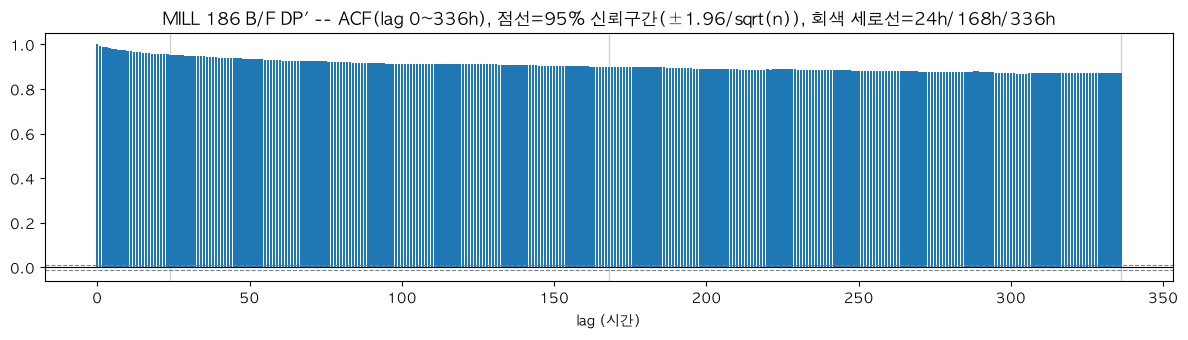

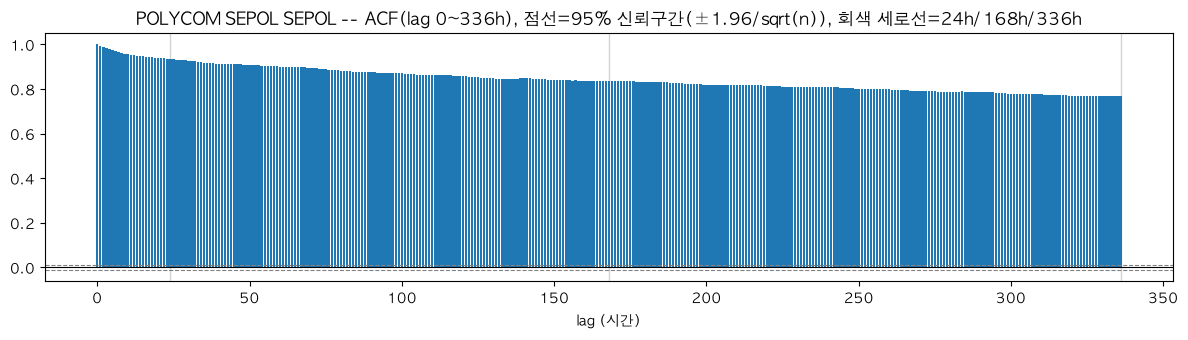

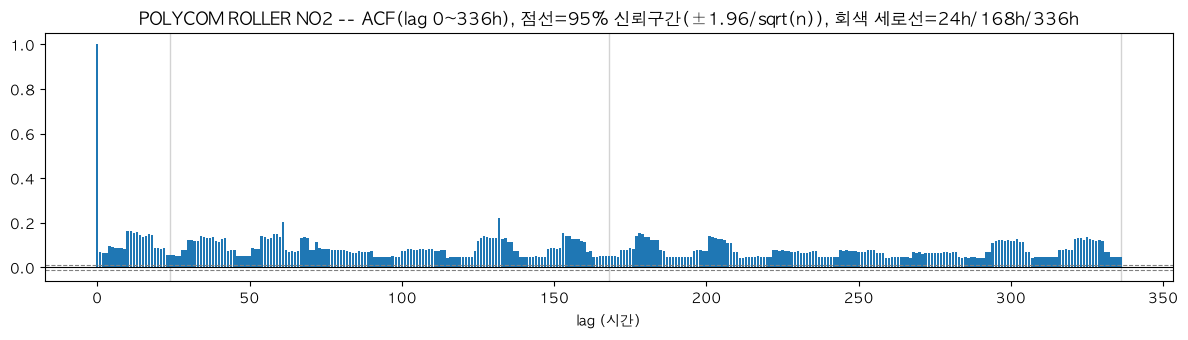

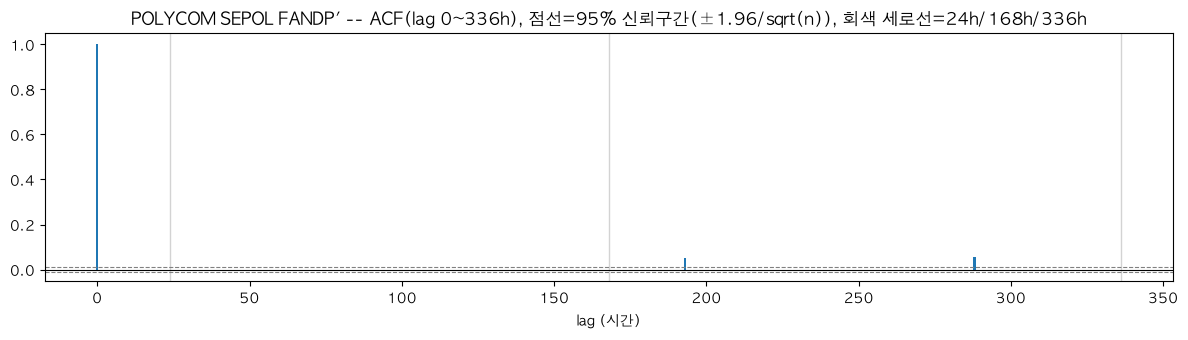

In [12]:
# ===================== 변수별 자기상관(ACF) 분석 =====================
# 각 변수가 "자기 자신의 과거값과 얼마나 관련 있는지"(자기상관, autocorrelation)를 봅니다.
# ACF가 낮으면(0 근처) 그 변수는 과거값만으로는 예측하기 어렵다는 뜻 -- Chronos R²가 낮게 나온
# 변수와 실제로 자기상관도 낮은지 서로 대조해볼 수 있음.
#
# 시간 갭(reindex로 NaN 처리된 부분)이 있어서 pandas의 `.dropna().autocorr(lag=k)`는 쓰면 안 됨
# (dropna를 먼저 하면 배열이 압축되면서 "lag k"가 실제 시간 간격과 안 맞게 됨 -- 실제로 확인된 버그).
# 대신 압축하지 않고 "실제 시간 위치" 기준으로 두 값이 모두 있는 쌍만 골라서(pairwise deletion)
# 상관계수를 계산합니다.

def compute_acf(x: np.ndarray, max_lag: int) -> np.ndarray:
    """x: 1시간 grid 기준 값 배열(NaN 포함 가능). 반환: lag 0~max_lag의 ACF 배열."""
    acf = np.full(max_lag + 1, np.nan)
    for k in range(max_lag + 1):
        if k == 0:
            acf[k] = 1.0
            continue
        a, b = x[k:], x[:-k]
        mask = ~np.isnan(a) & ~np.isnan(b)
        if mask.sum() < 10:
            continue
        acf[k] = np.corrcoef(a[mask], b[mask])[0, 1]
    return acf


ACF_MAX_LAG = 336  # 2주 (24 * 14)

_acf_by_var = {col: compute_acf(data[col].to_numpy(dtype=np.float64), ACF_MAX_LAG) for col in variable_cols}
acf_lag1 = pd.Series({col: v[1] for col, v in _acf_by_var.items()}, name="acf_lag1")
print(f"[{CURRENT_EQUIPMENT}] 변수 {len(acf_lag1)}개 자기상관(lag 0~{ACF_MAX_LAG}h) 계산 완료")


def plot_acf_overview(acf_series=None):
    acf_series = acf_lag1 if acf_series is None else acf_series
    s = acf_series.dropna().sort_values(ascending=False)
    labels = [c.replace("\n", " ") for c in s.index]

    fig, ax = plt.subplots(figsize=(max(10, len(s) * 0.35), 4))
    ax.plot(range(len(s)), s.values, marker="o", markersize=4, color="teal", linewidth=1.2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(f"[{CURRENT_EQUIPMENT}] 변수별 lag-1 자기상관(ACF) "
                 f"-- 높을수록 바로 직전 값 하나로도 다음 값 예측이 쉬움")
    plt.tight_layout()
    plt.show()


def plot_acf_detail(col, max_lag=ACF_MAX_LAG):
    label = col.replace("\n", " ")
    acf = _acf_by_var[col]
    n = data[col].notna().sum()
    ci = 1.96 / np.sqrt(n)

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.bar(range(max_lag + 1), acf, width=0.8, color="tab:blue")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(ci, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(-ci, color="gray", linestyle="--", linewidth=0.8)
    for k in (24, 168, 336):
        if k <= max_lag:
            ax.axvline(k, color="lightgray", linewidth=1, zorder=0)
    ax.set_title(f"{label} -- ACF(lag 0~{max_lag}h), 점선=95% 신뢰구간(±1.96/sqrt(n)), "
                 f"회색 세로선=24h/168h/336h")
    ax.set_xlabel("lag (시간)")
    plt.tight_layout()
    plt.show()


plot_acf_overview()

# R² 높은/낮은 변수 몇 개를 골라 자기상관 구조를 자세히 대조 (accuracy_summary는 위에서 이미 계산됨)
_acf_top = accuracy_summary.sort_values("r2", ascending=False)["variable"].head(2).tolist()
_acf_bottom = accuracy_summary.sort_values("r2", ascending=True)["variable"].head(2).tolist()
print("\nR² 높은 변수(예측 잘 됨) vs 낮은 변수(예측 잘 안 됨)의 자기상관 구조 비교:")
for _col in _acf_top + _acf_bottom:
    plot_acf_detail(_col)


# Chronos-2 Full 파인튜닝: GitHub review_v2 재현

- 예측 길이: **1시간** (`prediction_length=1`)
- 대상: 품질 변수와 `POLYCOM 운전시간`을 제외한 공정 변수 38개
- 입력 보조 변수: `POLYCOM 운전시간`은 past covariate로만 사용
- 분할: 2CM·3CM·4CM 각각 시간순 **70% 학습 / 15% 검증 / 15% 테스트**
- 검증: 각 설비의 검증 기간 전반에서 최대 128개 윈도우를 결정론적으로 선택
- 파인튜닝: `full`, learning rate `1e-6`, 1,000 steps, batch size 64, seed 42
- 테스트 구간은 학습과 모델 선택에 사용하지 않고 마지막 비교에만 사용

Full 파인튜닝은 시간이 오래 걸리므로 아래 셀을 순서대로 직접 실행합니다. 출력 폴더가 이미 비어 있지
않으면 기존 체크포인트를 덮어쓰지 않고 오류를 냅니다.


In [13]:
# ===================== Full 파인튜닝 CONFIG =====================
FT_TRAIN_FRAC = 0.70
FT_VAL_FRAC = 0.15
FT_TEST_FRAC = 0.15
FT_CONTEXT_LENGTH = CONTEXT_LENGTH
FT_PREDICTION_LENGTH = PREDICTION_LENGTH
FT_VALIDATION_WINDOWS_PER_EQUIPMENT = 128
FT_NUM_STEPS = 1000
FT_BATCH_SIZE = 64
FT_LEARNING_RATE = 1e-6
FT_MODE = "full"
FT_SEED = 42
FT_OUTPUT_DIR = Path("checkpoints") / PROTOCOL_VERSION / "all_process_full_pred1"
FINETUNED_MODEL_DIR = FT_OUTPUT_DIR / "final"

assert FT_PREDICTION_LENGTH == 1
print(f"mode={FT_MODE}, pred_len={FT_PREDICTION_LENGTH}, context={FT_CONTEXT_LENGTH}, "
      f"steps={FT_NUM_STEPS}, batch={FT_BATCH_SIZE}, lr={FT_LEARNING_RATE}, seed={FT_SEED}")


mode=full, pred_len=1, context=168, steps=1000, batch=64, lr=1e-06, seed=42


In [14]:
# ===================== 시간순 70/15/15 분할 + 검증 윈도우 구성 =====================
if PREPROCESSED_CSV.exists():
    ft_full_df = pd.read_csv(PREPROCESSED_CSV, parse_dates=["timestamp"])
else:
    _frames = []
    for _eid in EQUIPMENT_IDS:
        _data, _time, _targets, _, _ = load_data(_eid)
        _frames.append(equipment_frame(_eid, _data, _time, _targets))
    ft_full_df = pd.concat(_frames, ignore_index=True)
    PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    ft_full_df.to_csv(PREPROCESSED_CSV, index=False, encoding="utf-8-sig")

ft_variable_cols = [c for c in ft_full_df.columns if c not in ["item_id", "timestamp", DOWNTIME_COL]]
assert not set(QUALITY_COLS).intersection(ft_variable_cols)
assert DOWNTIME_COL not in ft_variable_cols

ft_train_df, ft_val_df, ft_test_df = chronological_split(
    ft_full_df, train_frac=FT_TRAIN_FRAC, val_frac=FT_VAL_FRAC,
)
ft_val_windows_df, ft_validation_manifest = validation_windows(
    ft_train_df, ft_val_df, ft_variable_cols,
    prediction_length=FT_PREDICTION_LENGTH, context_length=FT_CONTEXT_LENGTH,
    windows_per_item=FT_VALIDATION_WINDOWS_PER_EQUIPMENT,
)
train_inputs = to_chronos_inputs(ft_train_df, ft_variable_cols, FT_PREDICTION_LENGTH)
val_inputs = to_chronos_inputs(ft_val_windows_df, ft_variable_cols, FT_PREDICTION_LENGTH)
for _window in val_inputs:
    _labels = _window["context"][:_window["n_targets"], -FT_PREDICTION_LENGTH:]
    if not torch.isfinite(_labels).any().item():
        raise ValueError("검증 윈도우의 예측 구간에 유효한 target이 없습니다.")

print(pd.DataFrame({
    "train": ft_train_df.groupby("item_id").size(),
    "validation": ft_val_df.groupby("item_id").size(),
    "test": ft_test_df.groupby("item_id").size(),
}))
print(ft_validation_manifest.groupby("item_id").agg(
    windows=("window_id", "size"), observed_labels=("observed_labels", "sum"),
    first_forecast=("forecast_start", "min"), last_forecast=("forecast_end", "max"),
))
print(f"targets={len(ft_variable_cols)}, train_inputs={len(train_inputs)}, val_inputs={len(val_inputs)}")


         train  validation  test
item_id                         
2CM      35846        7681  7682
3CM      35846        7681  7682
4CM      35846        7681  7682
         windows  observed_labels      first_forecast       last_forecast
item_id                                                                  
2CM          128             4363 2024-02-16 22:00:00 2025-01-01 14:00:00
3CM          128             4485 2024-02-16 22:00:00 2025-01-01 14:00:00
4CM          128             4488 2024-02-17 00:00:00 2025-01-01 14:00:00
targets=38, train_inputs=3, val_inputs=384


In [15]:
# ===================== Full 파인튜닝 실행/기존 체크포인트 재사용 =====================
import json
import time
from transformers import set_seed

def run_or_load_full_finetune():
    # 이미 완료된 모델이 있으면 24분 학습을 반복하지 않고 바로 불러옵니다.
    if FINETUNED_MODEL_DIR.exists():
        loaded = BaseChronosPipeline.from_pretrained(
            FINETUNED_MODEL_DIR, device_map=DEVICE, torch_dtype=torch.float32,
        )
        print(f"기존 Full 체크포인트 재사용: {FINETUNED_MODEL_DIR}")
        return loaded

    if FT_OUTPUT_DIR.exists() and any(FT_OUTPUT_DIR.iterdir()):
        raise FileExistsError(
            f"완료 모델 없이 기존 파일이 있습니다. 확인 후 폴더를 정리하세요: {FT_OUTPUT_DIR}"
        )
    FT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    ft_validation_manifest.to_csv(FT_OUTPUT_DIR / "validation_windows.csv", index=False)

    metadata = {
        "protocol": PROTOCOL_VERSION,
        "variant": "review_v2",
        "status": "started",
        "model_id": MODEL_ID,
        "prediction_length": FT_PREDICTION_LENGTH,
        "context_length": FT_CONTEXT_LENGTH,
        "target_columns": ft_variable_cols,
        "past_covariates": [DOWNTIME_COL],
        "split": {"train": FT_TRAIN_FRAC, "validation": FT_VAL_FRAC, "test": FT_TEST_FRAC},
        "finetune_mode": FT_MODE,
        "learning_rate": FT_LEARNING_RATE,
        "num_steps": FT_NUM_STEPS,
        "batch_size": FT_BATCH_SIZE,
        "seed": FT_SEED,
        "source_xlsx_sha256": file_sha256(EXCEL_PATH),
        "processed_csv_sha256": file_sha256(PREPROCESSED_CSV),
        "versions": runtime_versions(),
        "validation_windows": len(ft_validation_manifest),
        "validation_observed_labels": int(ft_validation_manifest["observed_labels"].sum()),
    }
    (FT_OUTPUT_DIR / "run_metadata.json").write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8",
    )

    set_seed(FT_SEED)
    callback = make_loss_history_callback()
    started = time.time()
    trained = pipeline.fit(
        inputs=train_inputs,
        prediction_length=FT_PREDICTION_LENGTH,
        validation_inputs=val_inputs,
        finetune_mode=FT_MODE,
        learning_rate=FT_LEARNING_RATE,
        num_steps=FT_NUM_STEPS,
        batch_size=FT_BATCH_SIZE,
        context_length=FT_CONTEXT_LENGTH,
        output_dir=FT_OUTPUT_DIR,
        finetuned_ckpt_name="finetuned-ckpt",
        callbacks=[callback],
        seed=FT_SEED,
        data_seed=FT_SEED,
    )
    elapsed = time.time() - started
    trained.save_pretrained(FINETUNED_MODEL_DIR)
    history = loss_history_from_callback(callback)
    history.to_csv(FT_OUTPUT_DIR / "loss_history.csv", index=False)
    if history["val_loss"].dropna().empty:
        raise RuntimeError("유효한 validation loss가 기록되지 않아 완료로 표시하지 않습니다.")
    metadata["status"] = "complete"
    metadata["elapsed_minutes"] = elapsed / 60
    (FT_OUTPUT_DIR / "run_metadata.json").write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8",
    )
    print(f"Full 파인튜닝 완료: {FINETUNED_MODEL_DIR} ({elapsed/60:.1f}분)")
    return trained

pipeline_ft = run_or_load_full_finetune()


/Users/hxxungg/Desktop/Kitech/LS/Code/Anomarly Detection/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss
100,0.174416,0.265403
200,0.174504,0.265014
300,0.179887,0.263077
400,0.177397,0.261445
500,0.208745,0.260955
600,0.196548,0.260942
700,0.203049,0.260340
800,0.198607,0.260308
900,0.191442,0.260169
1000,0.185467,0.260128


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Full 파인튜닝 완료: checkpoints/review_v2_process_pred1/all_process_full_pred1/final (24.0분)


In [16]:
# ===================== 손대지 않은 테스트 15%에서 zero-shot과 Full 모델 재예측 =====================
def evaluate_on_test(model, context_full_df=None, scale_train_df=None, actual_full_df=None):
    # context_full_df: 모델 입력에 사용할 데이터. None이면 물리 기준만 정리한 ft_full_df 사용.
    # scale_train_df: severity 표준편차 계산용 학습 데이터. None이면 물리 기준 train 사용.
    # actual_full_df: 채점 실제값. None이면 물리 기준만 정리한 ft_full_df 사용.
    context_full_df = ft_full_df if context_full_df is None else context_full_df
    scale_train_df = ft_train_df if scale_train_df is None else scale_train_df
    actual_full_df = ft_full_df if actual_full_df is None else actual_full_df
    output = []
    for equipment_id in EQUIPMENT_IDS:
        full_group = actual_full_df.loc[actual_full_df["item_id"].eq(equipment_id)].sort_values("timestamp").reset_index(drop=True)
        context_group = context_full_df.loc[context_full_df["item_id"].eq(equipment_id)].sort_values("timestamp").reset_index(drop=True)
        if not full_group[["item_id", "timestamp"]].equals(context_group[["item_id", "timestamp"]]):
            raise ValueError(f"{equipment_id}: 채점 데이터와 입력 데이터의 시간축이 다릅니다.")
        train_group = ft_train_df.loc[ft_train_df["item_id"].eq(equipment_id)]
        scale_group = scale_train_df.loc[scale_train_df["item_id"].eq(equipment_id)]
        test_group = ft_test_df.loc[ft_test_df["item_id"].eq(equipment_id)]
        test_start = test_group["timestamp"].min()
        test_start_idx = int(np.flatnonzero(full_group["timestamp"].ge(test_start).to_numpy())[0])
        slice_start = max(0, test_start_idx - FT_CONTEXT_LENGTH)
        eval_group = full_group.iloc[slice_start:].reset_index(drop=True)
        eval_context_group = context_group.iloc[slice_start:].reset_index(drop=True)
        eval_data = eval_context_group[[*ft_variable_cols, DOWNTIME_COL]].copy()
        eval_actual_data = eval_group[[*ft_variable_cols, DOWNTIME_COL]].copy()
        is_down = eval_actual_data[DOWNTIME_COL].eq(0).fillna(False).to_numpy()

        train_running = ~scale_group[DOWNTIME_COL].eq(0).fillna(False)
        variable_scale = scale_group.loc[train_running, ft_variable_cols].std().fillna(0.0).to_numpy()
        result = rolling_forecast_review_v2(
            model, eval_data, ft_variable_cols, variable_scale, is_down,
            actual_data=eval_actual_data,
            context_length=FT_CONTEXT_LENGTH, prediction_length=FT_PREDICTION_LENGTH,
            stride=STRIDE, batch_windows=BATCH_WINDOWS,
            quantile_low=ANOMALY_QUANTILE_LOW, quantile_high=ANOMALY_QUANTILE_HIGH,
            severity_eps=SEVERITY_EPS,
        )
        result["timestamp"] = [eval_group["timestamp"].iloc[i] for i in result["idx"]]
        result = result.loc[result["timestamp"].ge(test_start)].copy()
        result.insert(0, "equipment_id", equipment_id)
        output.append(result)
    return pd.concat(output, ignore_index=True)

all_results_zeroshot_test = evaluate_on_test(pipeline)
all_results_ft = evaluate_on_test(pipeline_ft)
print(f"zero-shot test rows={len(all_results_zeroshot_test):,}, full test rows={len(all_results_ft):,}")


zero-shot test rows=875,748, full test rows=875,748


=== 테스트 구간 전체 변수 평균: zero-shot -> Full 파인튜닝 ===
R²         : -0.183 -> 0.226  (높을수록 좋음)
RMSE       : 21.727 -> 17.786  (낮을수록 좋음)
MAPE(%)    : 5.29 -> 4.84  (낮을수록 좋음)
Accuracy(%): 94.71 -> 95.16  (높을수록 좋음)
coverage(%): 98.53 -> 97.66

R² 개선된 설비-변수: 103/110


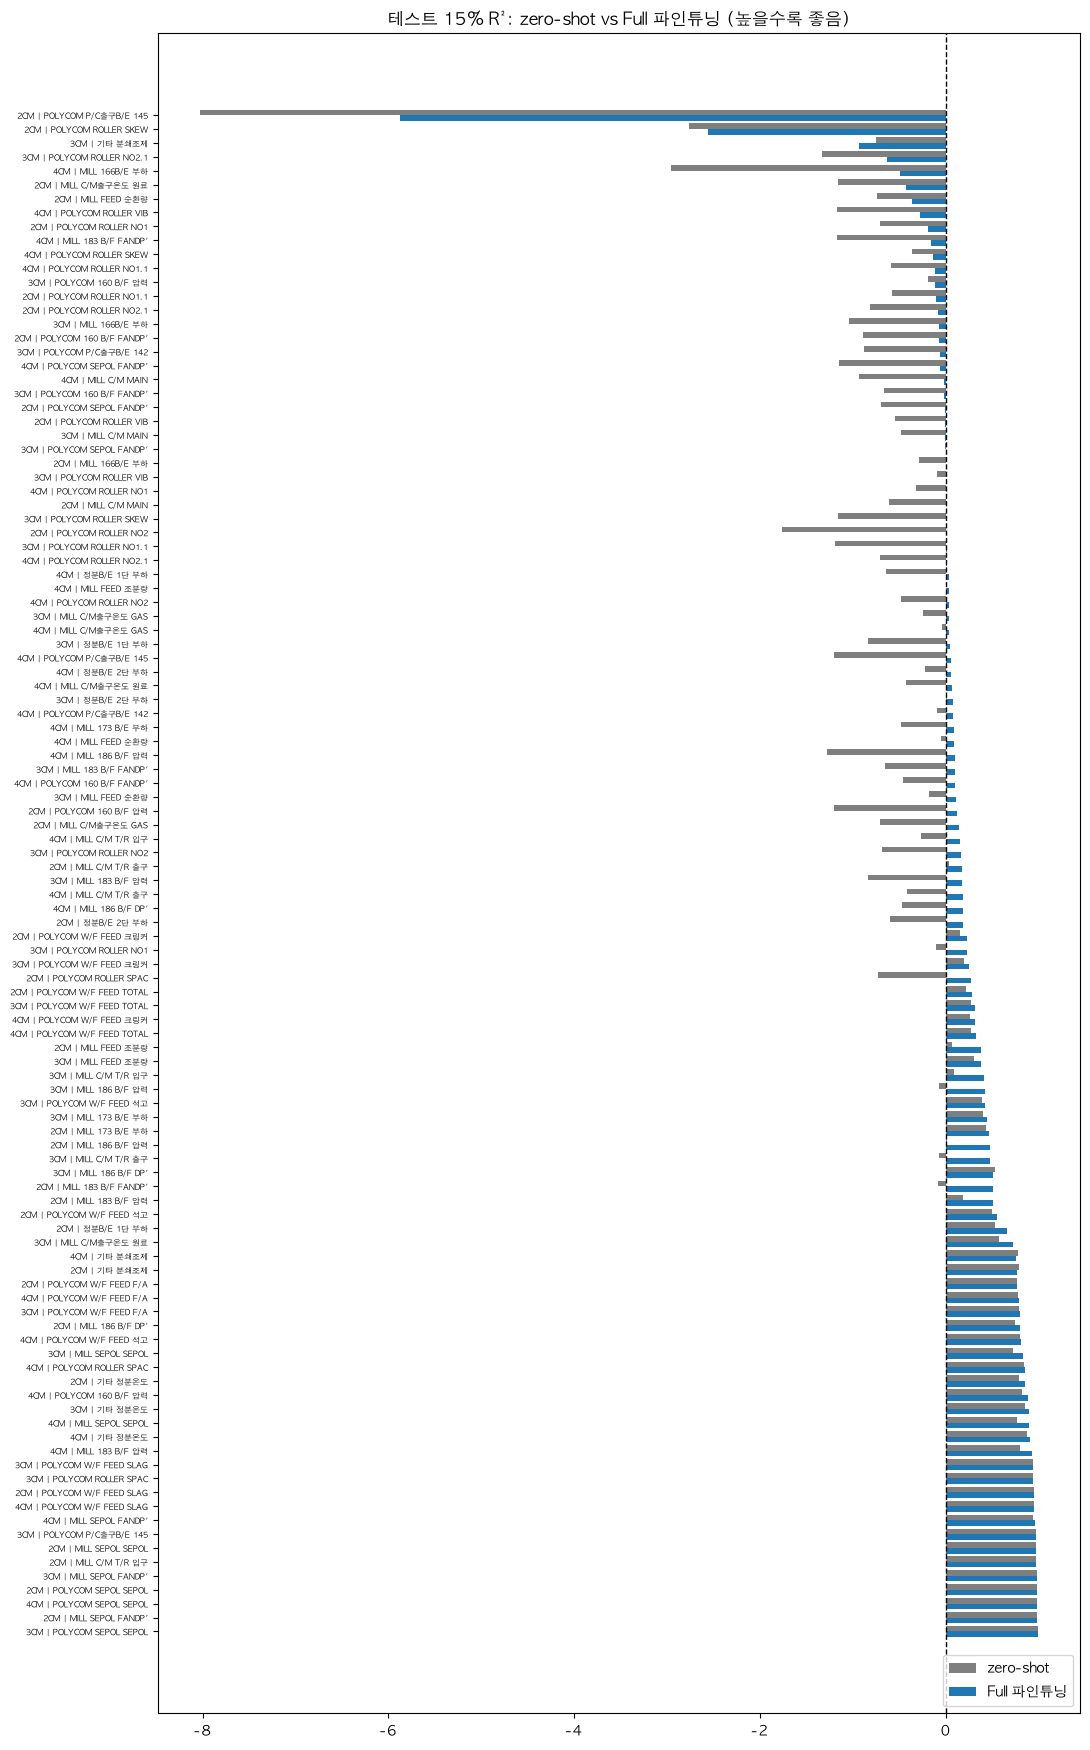

,equipment_id,variable,label,rmse_zeroshot,mape_zeroshot,accuracy_zeroshot,r2_zeroshot,coverage_zeroshot,n_scored_zeroshot,rmse_finetuned,mape_finetuned,accuracy_finetuned,r2_finetuned,coverage_finetuned,n_scored_finetuned
13,2CM,MILL\nSEPOL\nFANDP',MILL SEPOL FANDP',0.780804,0.086695,99.913305,0.989359,99.767245,4726,0.794043,0.085647,99.914353,0.988995,99.703766,4726
26,2CM,POLYCOM\nSEPOL\nSEPOL,POLYCOM SEPOL SEPOL,4.521775,0.512702,99.487298,0.987839,97.715736,4728,4.448445,0.485597,99.514403,0.988230,96.700508,4728
7,2CM,MILL\nC/M T/R\n입구,MILL C/M T/R 입구,1.278675,2.256703,97.743297,0.970135,99.301735,4726,1.093121,1.924122,98.075878,0.978174,98.307237,4726
14,2CM,MILL\nSEPOL\nSEPOL,MILL SEPOL SEPOL,9.380454,0.282469,99.717531,0.972120,98.391875,4726,8.659736,0.266978,99.733022,0.976239,96.720271,4726
28,2CM,POLYCOM\nW/F FEED\nSLAG,POLYCOM W/F FEED SLAG,1.094488,3.925293,96.074707,0.948751,97.798807,4861,1.080572,3.829031,96.170969,0.950046,96.770212,4861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,4CM,POLYCOM\nROLLER\nNO1.1,POLYCOM ROLLER NO1.1,53.060563,4.867713,95.132287,-0.585192,98.400692,4627,44.522880,4.217022,95.782978,-0.116104,97.665874,4627
96,4CM,POLYCOM\nROLLER\nSKEW,POLYCOM ROLLER SKEW,0.675668,28.390033,71.609967,-0.357430,98.292261,4626,0.616925,21.694936,78.305064,-0.131657,98.032858,4626
75,4CM,MILL\n183 B/F\nFANDP',MILL 183 B/F FANDP',2.453856,1.462419,98.537581,-1.173243,99.783877,4627,1.786245,1.308856,98.691144,-0.151574,99.783877,4627
98,4CM,POLYCOM\nROLLER\nVIB,POLYCOM ROLLER VIB,4.632961,25.793783,74.206217,-1.163747,98.293368,4629,3.552117,19.914393,80.085607,-0.271931,97.342839,4629


In [17]:
# ===================== 동일한 테스트 15%에서 zero-shot vs Full 비교 =====================
# naive 비교(mae_vs_naive)는 안 씀 -- 어차피 Full 파인튜닝을 무조건 진행하기로 했으므로
# "naive보다 나은지" 판정은 필요 없고, R²/RMSE/MAPE/Accuracy/Coverage로 zero-shot과
# Full을 직접 비교합니다.
def accuracy_by_equipment(result_df, model_name):
    parts = []
    for equipment_id, group in result_df.groupby("equipment_id", sort=False):
        acc = compute_accuracy_summary(group)
        acc.insert(0, "equipment_id", equipment_id)
        acc.insert(1, "model", model_name)
        parts.append(acc)
    return pd.concat(parts, ignore_index=True)

accuracy_summary_zeroshot_test = accuracy_by_equipment(all_results_zeroshot_test, "zero-shot")
accuracy_summary_ft = accuracy_by_equipment(all_results_ft, "full-finetuned")
metric_cols = ["rmse", "mape", "accuracy", "r2", "coverage", "n_scored"]
compare = accuracy_summary_zeroshot_test[["equipment_id", "variable", "label", *metric_cols]].merge(
    accuracy_summary_ft[["equipment_id", "variable", *metric_cols]],
    on=["equipment_id", "variable"], suffixes=("_zeroshot", "_finetuned"),
)

print("=== 테스트 구간 전체 변수 평균: zero-shot -> Full 파인튜닝 ===")
print(f"R²         : {compare['r2_zeroshot'].mean():.3f} -> {compare['r2_finetuned'].mean():.3f}  (높을수록 좋음)")
print(f"RMSE       : {compare['rmse_zeroshot'].mean():.3f} -> {compare['rmse_finetuned'].mean():.3f}  (낮을수록 좋음)")
print(f"MAPE(%)    : {compare['mape_zeroshot'].mean():.2f} -> {compare['mape_finetuned'].mean():.2f}  (낮을수록 좋음)")
print(f"Accuracy(%): {compare['accuracy_zeroshot'].mean():.2f} -> {compare['accuracy_finetuned'].mean():.2f}  (높을수록 좋음)")
print(f"coverage(%): {compare['coverage_zeroshot'].mean():.2f} -> {compare['coverage_finetuned'].mean():.2f}")
print(f"\nR² 개선된 설비-변수: {int((compare['r2_finetuned'] > compare['r2_zeroshot']).sum())}/{len(compare)}")

all_results_zeroshot_test.to_csv(FT_OUTPUT_DIR / "test_predictions_zeroshot.csv", index=False, encoding="utf-8-sig")
all_results_ft.to_csv(FT_OUTPUT_DIR / "test_predictions_full.csv", index=False, encoding="utf-8-sig")
compare.to_csv(FT_OUTPUT_DIR / "test_metrics_comparison.csv", index=False, encoding="utf-8-sig")

# 풀 파인튜닝 결과를 일반 Chronos 결과와 같은 long/wide 형식으로 설비별 저장합니다.
# 성능 누수를 피하기 위해 파일에는 손대지 않은 테스트 15% 결과만 들어갑니다.
def export_full_finetuned_csvs(result_df, metrics_df, variant):
    export_cols = ["equipment_id", "variable", "timestamp", "actual", "pred_median",
                   "pred_low", "pred_high", "error", "severity",
                   "is_anomaly", "excluded_reason"]
    saved = []
    for equipment_id, group in result_df.groupby("equipment_id", sort=False):
        export_df = group[export_cols].copy()
        export_df["variable"] = export_df["variable"].str.replace("\n", " ", regex=False)
        long_path = Path(f"chronos_anomaly_results_{equipment_id}__{variant}_full_finetuned_test.csv")
        export_df.to_csv(long_path, index=False, encoding="utf-8-sig")

        wide = group.copy()
        wide["variable"] = wide["variable"].str.replace("\n", " ", regex=False)
        wide = wide.pivot(index="timestamp", columns="variable", values="pred_median").reset_index()
        wide.insert(0, "ID", equipment_id)
        wide.insert(1, "근무일자", wide["timestamp"].dt.strftime("%Y-%m-%d"))
        wide.insert(2, "근무시간", wide["timestamp"].dt.hour)
        wide = wide.drop(columns=["timestamp"])
        wide_path = Path(f"chronos_predicted_원본형식_{equipment_id}__{variant}_full_finetuned_test.csv")
        wide.to_csv(wide_path, index=False, encoding="utf-8-sig")

        metric_path = Path(f"chronos_metrics_{equipment_id}__{variant}_full_finetuned_test.csv")
        metrics_df.loc[metrics_df["equipment_id"].eq(equipment_id)].to_csv(
            metric_path, index=False, encoding="utf-8-sig",
        )
        saved.extend([long_path, wide_path, metric_path])
        print(f"저장 완료: {long_path}, {wide_path}, {metric_path}")
    return saved

ft_review_v2_csvs = export_full_finetuned_csvs(
    all_results_ft, accuracy_summary_ft, variant="review_v2",
)

# 일반 Chronos와 Full 파인튜닝을 동일한 테스트 15%·동일 설비에서 같은 5개 지표 그래프로 확인합니다.
# 다른 설비를 보려면 아래 값을 '3CM' 또는 '4CM'으로 바꾸면 됩니다.
FT_PLOT_EQUIPMENT = "2CM"
_zs_plot = accuracy_summary_zeroshot_test.query("equipment_id == @FT_PLOT_EQUIPMENT").copy()
_ft_plot = accuracy_summary_ft.query("equipment_id == @FT_PLOT_EQUIPMENT").copy()
print(f"\n=== {FT_PLOT_EQUIPMENT}: 동일 테스트 15% 지표 그래프 ===")
plot_accuracy_summary(_zs_plot, title_prefix=f"테스트 15% · 일반 Chronos · {FT_PLOT_EQUIPMENT}")
plot_accuracy_summary(_ft_plot, title_prefix=f"테스트 15% · Full 파인튜닝 · {FT_PLOT_EQUIPMENT}")

comp_plot = compare.assign(key=lambda frame: frame["equipment_id"] + " | " + frame["label"])
comp_plot = comp_plot.sort_values("r2_finetuned")
fig, ax = plt.subplots(figsize=(11, max(7, len(comp_plot) * 0.16)))
y = np.arange(len(comp_plot))
ax.barh(y - 0.2, comp_plot["r2_zeroshot"], height=0.4, color="tab:gray", label="zero-shot")
ax.barh(y + 0.2, comp_plot["r2_finetuned"], height=0.4, color="tab:blue", label="Full 파인튜닝")
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(comp_plot["key"], fontsize=6)
ax.invert_yaxis()
ax.set_title("테스트 15% R²: zero-shot vs Full 파인튜닝 (높을수록 좋음)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

compare.sort_values(["equipment_id", "r2_finetuned"], ascending=[True, False])


# Full 파인튜닝 추가 실험: review_v2_tukey_iqr_trainfit

- `review_v2`: 고정 물리 기준 위반값만 NaN 처리한 기존 Full 파인튜닝
- `review_v2_tukey_iqr_trainfit`: 위 데이터의 학습 70%에 설비·변수별 Tukey 1.5×IQR 마스킹을 추가한 Full 파인튜닝
- 시간순으로 학습 70%·검증 15%·테스트 15%를 먼저 분할
- **학습 70%에서만** Q1/Q3 및 IQR 경계를 계산하고 학습 70%에만 적용
- Validation/Test 입력과 실제값은 IQR 미적용 원본을 유지하여 미적용 모델과 동일하게 비교


In [ ]:
# ===================== IQR Full 파인튜닝 독립 실행 초기화 =====================
# 커널을 재시작했거나 앞의 메인 파이프라인을 실행하지 않았어도 이 셀부터 실행할 수 있습니다.
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from chronos import BaseChronosPipeline
import importlib
import cement_chronos_review_v2 as _cement_review_v2
importlib.invalidate_caches()
_cement_review_v2 = importlib.reload(_cement_review_v2)
from cement_chronos_review_v2 import (
    DOWNTIME_COL, PROTOCOL_VERSION, QUALITY_COLS,
    apply_iqr_thresholds, chronological_split, file_sha256,
    fit_iqr_thresholds, loss_history_from_callback, make_loss_history_callback,
    rolling_forecast_multivariate as rolling_forecast_review_v2,
    runtime_versions, to_chronos_inputs, validation_windows,
)

MODEL_ID = "amazon/chronos-2"
EXCEL_PATH = "운전데이터_통합_2CM_3CM_4CM.xlsx"
EQUIPMENT_IDS = ["2CM", "3CM", "4CM"]
PREPROCESSED_CSV = Path("data/processed/process_timeseries_review_v2.csv")
IQR_MULTIPLIER = 1.5
ANOMALY_QUANTILE_LOW, ANOMALY_QUANTILE_HIGH = 0.01, 0.99
SEVERITY_EPS, STRIDE, BATCH_WINDOWS = 1e-3, 1, 128
FT_TRAIN_FRAC, FT_VAL_FRAC, FT_TEST_FRAC = 0.70, 0.15, 0.15
FT_CONTEXT_LENGTH, FT_PREDICTION_LENGTH = 168, 1
FT_VALIDATION_WINDOWS_PER_EQUIPMENT = 128
FT_NUM_STEPS, FT_BATCH_SIZE, FT_LEARNING_RATE = 1000, 64, 1e-6
FT_MODE, FT_SEED = "full", 42
FT_OUTPUT_DIR = Path("checkpoints") / PROTOCOL_VERSION / "all_process_full_pred1"
FINETUNED_MODEL_DIR = FT_OUTPUT_DIR / "final"
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

FT_IQR_VARIANT = "review_v2_tukey_iqr_trainfit"
FT_IQR_OUTPUT_DIR = Path("checkpoints") / PROTOCOL_VERSION / "all_process_full_pred1_tukey_iqr_trainfit"
FINETUNED_IQR_MODEL_DIR = FT_IQR_OUTPUT_DIR / "final"

if not PREPROCESSED_CSV.exists():
    raise FileNotFoundError(f"전처리 CSV가 없습니다: {PREPROCESSED_CSV}")
ft_full_df = pd.read_csv(PREPROCESSED_CSV, parse_dates=["timestamp"])
ft_variable_cols = [c for c in ft_full_df.columns if c not in ["item_id", "timestamp", DOWNTIME_COL]]
assert len(ft_variable_cols) == 38, f"예측 변수가 38개가 아닙니다: {len(ft_variable_cols)}"
assert not set(QUALITY_COLS).intersection(ft_variable_cols)
ft_train_df, ft_val_df, ft_test_df = chronological_split(
    ft_full_df, train_frac=FT_TRAIN_FRAC, val_frac=FT_VAL_FRAC,
)

# ===================== Tukey IQR Full 파인튜닝 데이터 준비 =====================
# 시간순 분할을 먼저 하고, 학습 70%에서만 Q1/Q3 경계를 계산·적용합니다.
ft_iqr_thresholds = fit_iqr_thresholds(
    ft_train_df, ft_variable_cols, multiplier=IQR_MULTIPLIER,
)
ft_iqr_train_df, ft_iqr_train_mask_summary = apply_iqr_thresholds(
    ft_train_df, ft_iqr_thresholds, ft_variable_cols,
)
ft_iqr_val_df = ft_val_df.copy()
ft_iqr_test_df = ft_test_df.copy()

def _newly_masked_count(before, after):
    return int((before[ft_variable_cols].notna() & after[ft_variable_cols].isna()).to_numpy().sum())

ft_iqr_split_mask_summary = pd.DataFrame([
    {"split": "train", "masked": _newly_masked_count(ft_train_df, ft_iqr_train_df)},
    {"split": "validation", "masked": 0},
    {"split": "test", "masked": 0},
])

ft_iqr_val_windows_df, ft_iqr_validation_manifest = validation_windows(
    ft_iqr_train_df, ft_iqr_val_df, ft_variable_cols,
    prediction_length=FT_PREDICTION_LENGTH, context_length=FT_CONTEXT_LENGTH,
    windows_per_item=FT_VALIDATION_WINDOWS_PER_EQUIPMENT,
)
train_inputs_iqr = to_chronos_inputs(ft_iqr_train_df, ft_variable_cols, FT_PREDICTION_LENGTH)
val_inputs_iqr = to_chronos_inputs(ft_iqr_val_windows_df, ft_variable_cols, FT_PREDICTION_LENGTH)
for _window in val_inputs_iqr:
    _labels = _window["context"][:_window["n_targets"], -FT_PREDICTION_LENGTH:]
    if not torch.isfinite(_labels).any().item():
        raise ValueError("IQR 검증 윈도우의 예측 구간에 유효한 target이 없습니다.")

print("=== IQR Full 파인튜닝 입력 준비 완료 ===")
print("마스킹 순서: 시간순 70/15/15 분할 -> Train에서 Q1/Q3 계산 -> Train에만 Tukey 1.5×IQR 적용")
print(ft_iqr_split_mask_summary.to_string(index=False))
print(f"Train 마스킹={int(ft_iqr_train_mask_summary['masked'].sum()):,}")
print(f"train_inputs={len(train_inputs_iqr)}, val_inputs={len(val_inputs_iqr)}, "
      f"validation_windows={len(ft_iqr_validation_manifest)}")


In [ ]:
# ===================== Tukey IQR Full 파인튜닝 실행/기존 체크포인트 재사용 =====================
import json
import time
from transformers import set_seed

if FINETUNED_IQR_MODEL_DIR.exists():
    pipeline_ft_iqr = BaseChronosPipeline.from_pretrained(
        FINETUNED_IQR_MODEL_DIR, device_map=DEVICE, torch_dtype=torch.float32,
    )
    print(f"기존 IQR Full 체크포인트 재사용: {FINETUNED_IQR_MODEL_DIR}")
else:
    if FT_IQR_OUTPUT_DIR.exists() and any(FT_IQR_OUTPUT_DIR.iterdir()):
        raise FileExistsError(
            f"완료 모델 없이 기존 파일이 있습니다. 확인 후 폴더를 정리하세요: {FT_IQR_OUTPUT_DIR}"
        )
    FT_IQR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    ft_iqr_thresholds.to_csv(FT_IQR_OUTPUT_DIR / "iqr_thresholds_train_only.csv", index=False, encoding="utf-8-sig")
    ft_iqr_train_mask_summary.to_csv(FT_IQR_OUTPUT_DIR / "mask_summary_by_variable.csv", index=False, encoding="utf-8-sig")
    ft_iqr_split_mask_summary.to_csv(FT_IQR_OUTPUT_DIR / "mask_summary_by_split.csv", index=False, encoding="utf-8-sig")
    ft_iqr_validation_manifest.to_csv(FT_IQR_OUTPUT_DIR / "validation_windows.csv", index=False)

    ft_iqr_metadata = {
        "protocol": PROTOCOL_VERSION,
        "variant": FT_IQR_VARIANT,
        "status": "started",
        "model_id": MODEL_ID,
        "prediction_length": FT_PREDICTION_LENGTH,
        "context_length": FT_CONTEXT_LENGTH,
        "target_columns": ft_variable_cols,
        "past_covariates": [DOWNTIME_COL],
        "split": {"train": FT_TRAIN_FRAC, "validation": FT_VAL_FRAC, "test": FT_TEST_FRAC},
        "iqr_cleaning": {
            "q1": 0.25, "q3": 0.75, "multiplier": IQR_MULTIPLIER,
            "threshold_source": "train_70_percent_only",
            "applied_to": ["train"],
            "iqr_zero_masked": False,
            "validation_inputs_masked": False,
            "test_actuals_masked": False,
        },
        "finetune_mode": FT_MODE,
        "learning_rate": FT_LEARNING_RATE,
        "num_steps": FT_NUM_STEPS,
        "batch_size": FT_BATCH_SIZE,
        "seed": FT_SEED,
        "source_xlsx_sha256": file_sha256(EXCEL_PATH),
        "physical_processed_csv_sha256": file_sha256(PREPROCESSED_CSV),
        "thresholds_csv_sha256": file_sha256(FT_IQR_OUTPUT_DIR / "iqr_thresholds_train_only.csv"),
        "versions": runtime_versions(),
        "validation_windows": len(ft_iqr_validation_manifest),
        "validation_observed_labels": int(ft_iqr_validation_manifest["observed_labels"].sum()),
        "train_values_masked": int(ft_iqr_split_mask_summary.loc[ft_iqr_split_mask_summary["split"].eq("train"), "masked"].iloc[0]),
        "validation_values_masked": int(ft_iqr_split_mask_summary.loc[ft_iqr_split_mask_summary["split"].eq("validation"), "masked"].iloc[0]),
        "test_values_masked": int(ft_iqr_split_mask_summary.loc[ft_iqr_split_mask_summary["split"].eq("test"), "masked"].iloc[0]),
    }
    (FT_IQR_OUTPUT_DIR / "run_metadata.json").write_text(
        json.dumps(ft_iqr_metadata, ensure_ascii=False, indent=2), encoding="utf-8",
    )

    set_seed(FT_SEED)
    loss_callback_iqr = make_loss_history_callback()
    _ft_iqr_start = time.time()
    pipeline_iqr_base = BaseChronosPipeline.from_pretrained(
        MODEL_ID, device_map=DEVICE, torch_dtype=torch.float32,
    )
    print(f"IQR 재학습용 기본 모델 로드 완료: {MODEL_ID} on {DEVICE}")
    pipeline_ft_iqr = pipeline_iqr_base.fit(
        inputs=train_inputs_iqr,
        prediction_length=FT_PREDICTION_LENGTH,
        validation_inputs=val_inputs_iqr,
        finetune_mode=FT_MODE,
        learning_rate=FT_LEARNING_RATE,
        num_steps=FT_NUM_STEPS,
        batch_size=FT_BATCH_SIZE,
        context_length=FT_CONTEXT_LENGTH,
        output_dir=FT_IQR_OUTPUT_DIR,
        finetuned_ckpt_name="finetuned-ckpt",
        callbacks=[loss_callback_iqr],
        seed=FT_SEED,
        data_seed=FT_SEED,
    )
    _ft_iqr_elapsed = time.time() - _ft_iqr_start
    pipeline_ft_iqr.save_pretrained(FINETUNED_IQR_MODEL_DIR)
    loss_history_iqr = loss_history_from_callback(loss_callback_iqr)
    loss_history_iqr.to_csv(FT_IQR_OUTPUT_DIR / "loss_history.csv", index=False)
    if loss_history_iqr["val_loss"].dropna().empty:
        raise RuntimeError("유효한 IQR validation loss가 기록되지 않아 완료로 표시하지 않습니다.")
    ft_iqr_metadata["status"] = "complete"
    ft_iqr_metadata["elapsed_minutes"] = _ft_iqr_elapsed / 60
    (FT_IQR_OUTPUT_DIR / "run_metadata.json").write_text(
        json.dumps(ft_iqr_metadata, ensure_ascii=False, indent=2), encoding="utf-8",
    )
    print(f"IQR Full 파인튜닝 완료: {FINETUNED_IQR_MODEL_DIR} ({_ft_iqr_elapsed/60:.1f}분)")


In [ ]:
# ===================== IQR 평가/저장도 메인 파이프라인 없이 독립 실행 =====================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 이 셀만 독립 실행해도 그래프의 한글이 깨지지 않도록 폰트를 설정합니다.
_korean_font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]
_available_fonts = {font.name for font in fm.fontManager.ttflist}
_korean_font = next((font for font in _korean_font_candidates if font in _available_fonts), None)
if _korean_font is None:
    print("경고: 사용 가능한 한글 폰트를 찾지 못했습니다.")
else:
    plt.rcParams["font.family"] = _korean_font
    print(f"한글 폰트 적용: {_korean_font}")
plt.rcParams["axes.unicode_minus"] = False

def _compute_accuracy_summary(result_df, mape_min_abs=1e-6):
    rows = []
    for variable, sub in result_df.groupby("variable"):
        sort_column = "idx" if "idx" in sub.columns else "timestamp"
        sub = sub.sort_values(sort_column).reset_index(drop=True)
        actual = sub["actual"].to_numpy(dtype=float)
        pred = sub["pred_median"].to_numpy(dtype=float)
        scored = sub["excluded_reason"].isna().to_numpy()
        previous = np.roll(actual, 1)
        previous[0] = np.nan
        valid = scored & np.isfinite(previous) & np.isfinite(actual) & np.isfinite(pred)
        if valid.sum() < 2:
            continue
        actual_v, error = actual[valid], actual[valid] - pred[valid]
        rmse = float(np.sqrt(np.mean(error ** 2)))
        mape_mask = np.abs(actual_v) > mape_min_abs
        mape = float(np.mean(np.abs(error[mape_mask] / actual_v[mape_mask])) * 100) if mape_mask.any() else np.nan
        low = sub["pred_low"].to_numpy(dtype=float)[valid]
        high = sub["pred_high"].to_numpy(dtype=float)[valid]
        coverage = float(((actual_v >= low) & (actual_v <= high)).mean() * 100)
        ss_res = float(np.sum(error ** 2))
        ss_tot = float(np.sum((actual_v - actual_v.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        rows.append({
            "variable": variable, "label": variable.replace("\n", " "),
            "rmse": rmse, "mape": mape, "accuracy": 100 - mape,
            "r2": r2, "coverage": coverage, "n_scored": int(valid.sum()),
            "mape_n": int(mape_mask.sum()), "mape_skipped": int((~mape_mask).sum()),
        })
    return pd.DataFrame(rows)

def _accuracy_by_equipment(result_df, model_name):
    parts = []
    for equipment_id, group in result_df.groupby("equipment_id", sort=False):
        summary = _compute_accuracy_summary(group)
        summary.insert(0, "equipment_id", equipment_id)
        summary.insert(1, "model", model_name)
        parts.append(summary)
    return pd.concat(parts, ignore_index=True)

def _evaluate_on_test(model, context_full_df, scale_train_df, actual_full_df):
    output = []
    for equipment_id in EQUIPMENT_IDS:
        actual_group = actual_full_df.loc[actual_full_df["item_id"].eq(equipment_id)].sort_values("timestamp").reset_index(drop=True)
        context_group = context_full_df.loc[context_full_df["item_id"].eq(equipment_id)].sort_values("timestamp").reset_index(drop=True)
        if not actual_group[["item_id", "timestamp"]].equals(context_group[["item_id", "timestamp"]]):
            raise ValueError(f"{equipment_id}: 채점값과 입력값의 시간축이 다릅니다.")
        scale_group = scale_train_df.loc[scale_train_df["item_id"].eq(equipment_id)]
        test_start = ft_test_df.loc[ft_test_df["item_id"].eq(equipment_id), "timestamp"].min()
        test_start_idx = int(np.flatnonzero(actual_group["timestamp"].ge(test_start).to_numpy())[0])
        slice_start = max(0, test_start_idx - FT_CONTEXT_LENGTH)
        eval_actual = actual_group.iloc[slice_start:].reset_index(drop=True)
        eval_context = context_group.iloc[slice_start:].reset_index(drop=True)
        eval_data = eval_context[[*ft_variable_cols, DOWNTIME_COL]].copy()
        eval_actual_data = eval_actual[[*ft_variable_cols, DOWNTIME_COL]].copy()
        is_down = eval_actual_data[DOWNTIME_COL].eq(0).fillna(False).to_numpy()
        train_running = ~scale_group[DOWNTIME_COL].eq(0).fillna(False)
        variable_scale = scale_group.loc[train_running, ft_variable_cols].std().fillna(0.0).to_numpy()
        result = rolling_forecast_review_v2(
            model, eval_data, ft_variable_cols, variable_scale, is_down,
            actual_data=eval_actual_data, context_length=FT_CONTEXT_LENGTH,
            prediction_length=FT_PREDICTION_LENGTH, stride=STRIDE,
            batch_windows=BATCH_WINDOWS, quantile_low=ANOMALY_QUANTILE_LOW,
            quantile_high=ANOMALY_QUANTILE_HIGH, severity_eps=SEVERITY_EPS,
        )
        result["timestamp"] = [eval_actual["timestamp"].iloc[i] for i in result["idx"]]
        result = result.loc[result["timestamp"].ge(test_start)].copy()
        result.insert(0, "equipment_id", equipment_id)
        output.append(result)
    return pd.concat(output, ignore_index=True)

def _export_full_results(result_df, metrics_df, variant):
    for equipment_id, group in result_df.groupby("equipment_id", sort=False):
        export_df = group[["equipment_id", "variable", "timestamp", "actual", "pred_median",
                           "pred_low", "pred_high", "error", "severity",
                           "is_anomaly", "excluded_reason"]].copy()
        export_df["variable"] = export_df["variable"].str.replace("\n", " ", regex=False)
        export_df.to_csv(f"chronos_anomaly_results_{equipment_id}__{variant}_full_finetuned_test.csv", index=False, encoding="utf-8-sig")
        wide = group.assign(variable=group["variable"].str.replace("\n", " ", regex=False)).pivot(
            index="timestamp", columns="variable", values="pred_median",
        ).reset_index()
        wide.insert(0, "ID", equipment_id)
        wide.insert(1, "근무일자", wide["timestamp"].dt.strftime("%Y-%m-%d"))
        wide.insert(2, "근무시간", wide["timestamp"].dt.hour)
        wide.drop(columns="timestamp").to_csv(
            f"chronos_predicted_원본형식_{equipment_id}__{variant}_full_finetuned_test.csv",
            index=False, encoding="utf-8-sig",
        )
        metrics_df.loc[metrics_df["equipment_id"].eq(equipment_id)].to_csv(
            f"chronos_metrics_{equipment_id}__{variant}_full_finetuned_test.csv",
            index=False, encoding="utf-8-sig",
        )

def _plot_five_metrics(summary, title, variable_order=None, metric_limits=None):
    shown = summary.copy()
    shown["variable"] = shown["variable"].astype(str).str.replace("\n", " ", regex=False).str.strip()
    shown["label"] = shown["label"].astype(str).str.replace("\n", " ", regex=False)
    shown = shown.drop_duplicates(subset=["variable"], keep="first")
    if variable_order is None:
        shown = shown.dropna(subset=["r2"]).sort_values("r2", ascending=False).reset_index(drop=True)
    else:
        shown = shown.set_index("variable").reindex(variable_order).reset_index()
        shown["label"] = shown["label"].fillna(shown["variable"].astype(str).str.replace("\n", " ", regex=False))
    x = np.arange(len(shown))
    specs = [("r2", "R²", "tab:green"), ("rmse", "RMSE", "tab:red"),
             ("accuracy", "Accuracy (%)", "tab:blue"),
             ("mape", "MAPE (%)", "tab:orange"),
             ("coverage", "Coverage (%)", "tab:purple")]
    fig, axes = plt.subplots(5, 1, figsize=(max(11, len(shown) * 0.35), 19), sharex=True)
    for ax, (column, label, color) in zip(axes, specs):
        values = pd.to_numeric(shown[column], errors="coerce").to_numpy(dtype=float)
        if column == "r2":
            # R²는 아래쪽 제한이 없으므로 극단적인 음수 하나가 그래프 전체를 압축하지 않게
            # 표시 범위만 -2~1.05로 제한합니다. 계산값과 저장 CSV는 변경하지 않습니다.
            display_min, display_max = -2.0, 1.05
            plot_values = np.clip(values, display_min, display_max)
            ax.plot(x, plot_values, marker="o", markersize=3, color=color)
            below = np.isfinite(values) & (values < display_min)
            if below.any():
                ax.scatter(x[below], np.full(below.sum(), display_min), marker="v",
                           s=34, color=color, zorder=4, label="실제 R² < -2")
                ax.legend(fontsize=8, loc="lower left")
            ax.set_ylim(display_min, display_max)
            ax.set_ylabel("R² (▼: 실제값 < -2)")
        else:
            ax.plot(x, values, marker="o", markersize=3, color=color)
        ax.set_title(f"{title} — {label}")
        ax.set_xticks(x)
        ax.set_xticklabels(shown["label"], rotation=90, fontsize=7)
        ax.tick_params(axis="x", labelbottom=True)
        if column != "r2" and metric_limits is not None and column in metric_limits:
            ax.set_ylim(*metric_limits[column])
    axes[4].axhline((ANOMALY_QUANTILE_HIGH - ANOMALY_QUANTILE_LOW) * 100, color="black", linestyle="--")
    plt.tight_layout(pad=2.0, h_pad=2.0)
    plt.show()

def _shared_metric_plot_config(summaries):
    # 네 결과의 전체 변수를 같은 위치에 두고, 각 지표의 y축도 동일하게 맞춥니다.
    prepared = []
    for summary in summaries:
        frame = summary.copy()
        frame["variable"] = frame["variable"].astype(str).str.replace("\n", " ", regex=False).str.strip()
        frame["label"] = frame["label"].astype(str).str.replace("\n", " ", regex=False)
        frame = frame.drop_duplicates(subset=["variable"], keep="first")
        prepared.append(frame)
    all_variables = set().union(*(set(frame["variable"].dropna()) for frame in prepared))
    if not all_variables:
        raise ValueError("표시할 평가 변수가 없습니다.")
    base = prepared[0].loc[prepared[0]["variable"].isin(all_variables)]
    variable_order = base.sort_values("r2", ascending=False, na_position="last")["variable"].tolist()
    ordered_set = set(variable_order)
    for frame in prepared[1:]:
        extras = frame.loc[~frame["variable"].isin(ordered_set)].sort_values("r2", ascending=False, na_position="last")
        variable_order.extend(extras["variable"].tolist())
        ordered_set.update(extras["variable"])

    metric_limits = {}
    for column in ["r2", "rmse", "accuracy", "mape", "coverage"]:
        if column == "r2":
            metric_limits[column] = (-2.0, 1.05)
            continue
        values = pd.concat([
            pd.to_numeric(frame.loc[frame["variable"].isin(variable_order), column], errors="coerce")
            for frame in prepared
        ], ignore_index=True)
        values = values[np.isfinite(values)]
        if values.empty:
            continue
        value_min, value_max = float(values.min()), float(values.max())
        span = value_max - value_min
        reference = max(abs(value_min), abs(value_max), 1.0)
        padding = max(0.10, span * 0.08, reference * 0.03)
        lower, upper = value_min - padding, value_max + padding
        if column in {"rmse", "mape"}:
            lower = -max(0.10, value_max * 0.02)
        metric_limits[column] = (lower, upper)
    return variable_order, metric_limits

def _mean_metric_row(summary, model_name):
    return {
        "model": model_name,
        "R2": summary["r2"].mean(),
        "RMSE": summary["rmse"].mean(),
        "Accuracy(%)": summary["accuracy"].mean(),
        "MAPE(%)": summary["mape"].mean(),
        "Coverage(%)": summary["coverage"].mean(),
    }

def _rescore_predictions_on_common_test(result_df, actual_test_df, scale_train_df):
    """기존 예측값은 유지하고 물리 기준만 적용한 동일 테스트 실제값으로 다시 채점합니다."""
    result = result_df.copy()
    result["timestamp"] = pd.to_datetime(result["timestamp"])
    result["variable_key"] = result["variable"].astype(str).str.replace("\n", " ", regex=False).str.strip()

    actual_long = actual_test_df[["item_id", "timestamp", DOWNTIME_COL, *ft_variable_cols]].melt(
        id_vars=["item_id", "timestamp", DOWNTIME_COL],
        value_vars=ft_variable_cols, var_name="variable_key", value_name="actual_common",
    )
    actual_long = actual_long.rename(columns={"item_id": "equipment_id"})
    actual_long["variable_key"] = actual_long["variable_key"].astype(str).str.replace("\n", " ", regex=False).str.strip()
    actual_long["timestamp"] = pd.to_datetime(actual_long["timestamp"])

    drop_columns = ["actual", "error", "severity", "is_anomaly", "excluded_reason"]
    result = result.drop(columns=drop_columns, errors="ignore").merge(
        actual_long, on=["equipment_id", "timestamp", "variable_key"],
        how="left", validate="many_to_one", indicator=True,
    )
    if not result["_merge"].eq("both").all():
        raise ValueError("공통 테스트 실제값과 연결되지 않은 예측 행이 있습니다.")
    result = result.drop(columns="_merge")

    scale_rows = []
    for equipment_id, group in scale_train_df.groupby("item_id", sort=False):
        running = ~group[DOWNTIME_COL].eq(0).fillna(False)
        scales = group.loc[running, ft_variable_cols].std().fillna(0.0)
        for variable, scale in scales.items():
            scale_rows.append({
                "equipment_id": equipment_id,
                "variable_key": str(variable).replace("\n", " ").strip(),
                "_scale": float(scale),
            })
    result = result.merge(pd.DataFrame(scale_rows), on=["equipment_id", "variable_key"], how="left", validate="many_to_one")

    result["actual"] = pd.to_numeric(result.pop("actual_common"), errors="coerce")
    pred = pd.to_numeric(result["pred_median"], errors="coerce")
    low = pd.to_numeric(result["pred_low"], errors="coerce")
    high = pd.to_numeric(result["pred_high"], errors="coerce")
    actual_missing = result["actual"].isna()
    is_down = result[DOWNTIME_COL].eq(0).fillna(False)
    result["excluded_reason"] = np.select(
        [actual_missing, is_down], ["gap_or_cleaned", "down"], default=None,
    )
    result["error"] = result["actual"] - pred
    result.loc[actual_missing, "error"] = np.nan
    result["severity"] = result["error"].abs() / result["_scale"].clip(lower=SEVERITY_EPS)
    result["is_anomaly"] = (
        result["excluded_reason"].isna()
        & result["actual"].notna() & low.notna() & high.notna()
        & ((result["actual"] < low) | (result["actual"] > high))
    )
    return result.drop(columns=[DOWNTIME_COL, "_scale", "variable_key"])

# 저장된 결과를 복원하므로 기존 메인 예측은 다시 돌리지 않습니다.
# IQR은 학습 데이터에만 적용하므로 학습 전 Zero-shot에는 IQR 적용/미적용 구분이 없습니다.
_zeroshot_path = FT_OUTPUT_DIR / "test_predictions_zeroshot.csv"
_baseline_path = FT_OUTPUT_DIR / "test_predictions_full.csv"
for _required_path in [_zeroshot_path, _baseline_path]:
    if not _required_path.exists():
        raise FileNotFoundError(f"저장된 비교 결과가 없습니다: {_required_path}")
all_results_zeroshot_test = pd.read_csv(_zeroshot_path, parse_dates=["timestamp"])
all_results_ft = pd.read_csv(_baseline_path, parse_dates=["timestamp"])
accuracy_summary_zeroshot = _accuracy_by_equipment(all_results_zeroshot_test, "zero-shot-no-iqr")
accuracy_summary_ft = _accuracy_by_equipment(all_results_ft, "full-finetuned")
metric_cols = ["rmse", "mape", "accuracy", "r2", "coverage", "n_scored"]

# 1. 파인튜닝 진행 전 결과를 먼저 표시합니다.
before_finetuning_summary = pd.DataFrame([
    _mean_metric_row(accuracy_summary_zeroshot, "파인튜닝 전 · 공통 Zero-shot"),
])
print("\n=== 1. 파인튜닝 진행 전: 테스트 15% 평균 성능 ===")
print("IQR은 학습 데이터에만 적용되므로 Zero-shot 결과는 하나입니다.")
print(before_finetuning_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
FT_PLOT_EQUIPMENT = globals().get("FT_PLOT_EQUIPMENT", "2CM")

# ===================== Full 파인튜닝: IQR 미적용 vs 적용 같은 테스트 기간 비교/CSV 저장 =====================
_ft_iqr_common_cache = FT_IQR_OUTPUT_DIR / "test_predictions_full_iqr_common_actual.csv"
if _ft_iqr_common_cache.exists():
    all_results_ft_iqr = pd.read_csv(_ft_iqr_common_cache, parse_dates=["timestamp"])
    print(f"동일 실제값 Full IQR 결과 재사용: {_ft_iqr_common_cache}")
else:
    all_results_ft_iqr = _evaluate_on_test(
        pipeline_ft_iqr, context_full_df=ft_full_df,
        scale_train_df=ft_train_df, actual_full_df=ft_full_df,
    )
    all_results_ft_iqr.to_csv(_ft_iqr_common_cache, index=False, encoding="utf-8-sig")
    print(f"동일 실제값 Full IQR 결과 저장: {_ft_iqr_common_cache}")
accuracy_summary_ft_iqr = _accuracy_by_equipment(all_results_ft_iqr, "full-finetuned-iqr")

# 2. 파인튜닝 완료 후 두 전처리 결과를 표시합니다.
after_finetuning_summary = pd.DataFrame([
    _mean_metric_row(accuracy_summary_ft, "파인튜닝 후 · IQR 미적용"),
    _mean_metric_row(accuracy_summary_ft_iqr, "파인튜닝 후 · IQR 적용"),
])
print("\n=== 2. 파인튜닝 진행 후: 테스트 15% 평균 성능 ===")
print(after_finetuning_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# 3. 파인튜닝 전후 네 결과를 한 표에서 비교합니다.
finetuning_comparison_summary = pd.concat(
    [before_finetuning_summary, after_finetuning_summary], ignore_index=True,
)
print("\n=== 3. 파인튜닝 전후 최종 비교 ===")
print(finetuning_comparison_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
finetuning_comparison_summary.to_csv(
    "chronos_metrics_before_after_finetuning_tukey_iqr_trainfit_common_actual_summary.csv", index=False, encoding="utf-8-sig",
)

compare_ft_preprocessing = accuracy_summary_ft[["equipment_id", "variable", "label", *metric_cols]].merge(
    accuracy_summary_ft_iqr[["equipment_id", "variable", *metric_cols]],
    on=["equipment_id", "variable"], suffixes=("_review_v2", "_review_v2_iqr"),
)
print("=== 같은 테스트 15% 기간의 전체 변수 평균: Full review_v2 -> Full review_v2_iqr ===")
print("비교 기준: 두 모델 모두 물리 기준만 적용한 동일 테스트 실제값으로 채점했습니다.")
print(f"R²         : {compare_ft_preprocessing['r2_review_v2'].mean():.3f} -> "
      f"{compare_ft_preprocessing['r2_review_v2_iqr'].mean():.3f}  (높을수록 좋음)")
print(f"RMSE       : {compare_ft_preprocessing['rmse_review_v2'].mean():.3f} -> "
      f"{compare_ft_preprocessing['rmse_review_v2_iqr'].mean():.3f}  (낮을수록 좋음)")
print(f"MAPE(%)    : {compare_ft_preprocessing['mape_review_v2'].mean():.2f} -> "
      f"{compare_ft_preprocessing['mape_review_v2_iqr'].mean():.2f}  (낮을수록 좋음)")
print(f"Accuracy(%): {compare_ft_preprocessing['accuracy_review_v2'].mean():.2f} -> "
      f"{compare_ft_preprocessing['accuracy_review_v2_iqr'].mean():.2f}  (높을수록 좋음)")
print(f"coverage(%): {compare_ft_preprocessing['coverage_review_v2'].mean():.2f} -> "
      f"{compare_ft_preprocessing['coverage_review_v2_iqr'].mean():.2f}")
print(f"R² 개선 변수: "
      f"{int((compare_ft_preprocessing['r2_review_v2_iqr'] > compare_ft_preprocessing['r2_review_v2']).sum())}/"
      f"{len(compare_ft_preprocessing)}")

all_results_ft_iqr.to_csv(FT_IQR_OUTPUT_DIR / "test_predictions_full_iqr_common_actual.csv", index=False, encoding="utf-8-sig")
accuracy_summary_ft_iqr.to_csv(FT_IQR_OUTPUT_DIR / "test_metrics_full_iqr_common_actual.csv", index=False, encoding="utf-8-sig")
compare_ft_preprocessing.to_csv(
    FT_IQR_OUTPUT_DIR / "test_metrics_review_v2_vs_iqr_common_actual.csv", index=False, encoding="utf-8-sig",
)
compare_ft_preprocessing.to_csv(
    "chronos_metrics_full_finetuned_review_v2_vs_tukey_iqr_trainfit_common_actual_test.csv", index=False, encoding="utf-8-sig",
)
_export_full_results(all_results_ft_iqr, accuracy_summary_ft_iqr, variant=f"{FT_IQR_VARIANT}_common_actual")

# 1단계: 파인튜닝 후 Tukey IQR 미적용/적용을 지표별 동일 축에서 비교합니다.
# 2단계: 이후에는 최종 선택 모델만 그 모델 값에 맞춘 축으로 표시합니다.
from plot_model_selection import (
    plot_final_no_percentile_metrics, plot_preprocessing_comparison,
)

FT_PLOT_EQUIPMENT = globals().get("FT_PLOT_EQUIPMENT", "2CM")
_ft_review_plot = accuracy_summary_ft.query("equipment_id == @FT_PLOT_EQUIPMENT").copy()
_ft_iqr_plot = accuracy_summary_ft_iqr.query("equipment_id == @FT_PLOT_EQUIPMENT").copy()

print(f"\n=== 4. {FT_PLOT_EQUIPMENT}: 전처리 선택 근거 · Tukey IQR 미적용 vs 적용 ===")
_preprocessing_figures = plot_preprocessing_comparison(
    _ft_review_plot, _ft_iqr_plot, equipment_id=FT_PLOT_EQUIPMENT,
    output_dir="model_comparison",
)
plt.show()

print(f"\n=== 5. {FT_PLOT_EQUIPMENT}: 최종 선택 모델 · Tukey IQR 미적용 전용 축 ===")
_final_figure, _, _final_metric_limits = plot_final_no_percentile_metrics(
    _ft_review_plot, equipment_id=FT_PLOT_EQUIPMENT, output_dir="model_comparison",
)
print(f"Tukey IQR 미적용 모델 기준 y축 범위: {_final_metric_limits}")
plt.show()

compare_ft_preprocessing.sort_values(
    ["equipment_id", "r2_review_v2_iqr"], ascending=[True, False],
)


In [ ]:
# ===================== 한글 폰트 적용 후 그래프만 다시 출력 =====================
# 위 결과 계산은 반복하지 않고, 저장된 성능 CSV로 그래프만 다시 그립니다.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

_korean_font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]
_available_fonts = {font.name for font in fm.fontManager.ttflist}
_korean_font = next((font for font in _korean_font_candidates if font in _available_fonts), None)
if _korean_font is None:
    raise RuntimeError("사용 가능한 한글 폰트를 찾지 못했습니다.")
plt.rcParams["font.family"] = _korean_font
plt.rcParams["axes.unicode_minus"] = False
print(f"한글 폰트 적용: {_korean_font}")

# 커널을 다시 시작했더라도 Tukey IQR 미적용 Full FT 지표를 저장 CSV에서 복원합니다.
_ft_metric_files = sorted(Path(".").glob("chronos_metrics_*__review_v2_full_finetuned_test.csv"))
if not _ft_metric_files:
    raise FileNotFoundError("Tukey IQR 미적용 Full 파인튜닝 지표 CSV를 찾지 못했습니다.")
accuracy_summary_ft = pd.concat(
    [pd.read_csv(path) for path in _ft_metric_files], ignore_index=True
)

# 동일한 물리 기준 테스트 실제값으로 재채점한 IQR 지표가 있으면 자동으로 사용합니다.
_ft_iqr_common_metrics = Path("checkpoints/review_v2_process_pred1/all_process_full_pred1_tukey_iqr_trainfit/test_metrics_full_iqr_common_actual.csv")
if _ft_iqr_common_metrics.exists():
    accuracy_summary_ft_iqr = pd.read_csv(_ft_iqr_common_metrics)
    print("Train 기반 Tukey IQR 결과를 동일한 원본 테스트 기준으로 표시합니다.")
else:
    raise FileNotFoundError(
        "학습 70% 경계로 재학습한 IQR 결과가 없습니다. IQR 데이터 준비, 재학습, 평가 셀을 순서대로 실행하세요."
    )

def _plot_five_metrics(summary, title, variable_order=None, metric_limits=None):
    shown = summary.copy()
    shown["variable"] = shown["variable"].astype(str).str.replace("\n", " ", regex=False).str.strip()
    shown["label"] = shown["label"].astype(str).str.replace("\n", " ", regex=False)
    shown = shown.drop_duplicates(subset=["variable"], keep="first")
    if variable_order is None:
        shown = shown.dropna(subset=["r2"]).sort_values("r2", ascending=False).reset_index(drop=True)
    else:
        shown = shown.set_index("variable").reindex(variable_order).reset_index()
        shown["label"] = shown["label"].fillna(shown["variable"].astype(str).str.replace("\n", " ", regex=False))
    x = np.arange(len(shown))
    specs = [("r2", "R²", "tab:green"), ("rmse", "RMSE", "tab:red"),
             ("accuracy", "Accuracy (%)", "tab:blue"),
             ("mape", "MAPE (%)", "tab:orange"),
             ("coverage", "Coverage (%)", "tab:purple")]
    fig, axes = plt.subplots(5, 1, figsize=(max(11, len(shown) * 0.35), 19), sharex=True)
    for ax, (column, label, color) in zip(axes, specs):
        ax.plot(x, shown[column], marker="o", markersize=3, color=color)
        ax.set_title(f"{title} — {label}")
        ax.set_xticks(x)
        ax.set_xticklabels(shown["label"], rotation=90, fontsize=7)
        ax.tick_params(axis="x", labelbottom=True)
        if metric_limits is not None and column in metric_limits:
            ax.set_ylim(*metric_limits[column])
    _coverage_target = (globals().get("ANOMALY_QUANTILE_HIGH", 0.99) - globals().get("ANOMALY_QUANTILE_LOW", 0.01)) * 100
    axes[4].axhline(_coverage_target, color="black", linestyle="--")
    plt.tight_layout(pad=2.0, h_pad=2.0)
    plt.show()

def _shared_metric_plot_config(summaries):
    prepared = []
    for summary in summaries:
        frame = summary.copy()
        frame["variable"] = frame["variable"].astype(str).str.replace("\n", " ", regex=False).str.strip()
        frame["label"] = frame["label"].astype(str).str.replace("\n", " ", regex=False)
        frame = frame.drop_duplicates(subset=["variable"], keep="first")
        prepared.append(frame)
    all_variables = set().union(*(set(frame["variable"].dropna()) for frame in prepared))
    if not all_variables:
        raise ValueError("표시할 평가 변수가 없습니다.")
    base = prepared[0].loc[prepared[0]["variable"].isin(all_variables)]
    variable_order = base.sort_values("r2", ascending=False, na_position="last")["variable"].tolist()
    ordered_set = set(variable_order)
    for frame in prepared[1:]:
        extras = frame.loc[~frame["variable"].isin(ordered_set)].sort_values("r2", ascending=False, na_position="last")
        variable_order.extend(extras["variable"].tolist())
        ordered_set.update(extras["variable"])
    metric_limits = {}
    for column in ["r2", "rmse", "accuracy", "mape", "coverage"]:
        values = pd.concat([
            pd.to_numeric(frame.loc[frame["variable"].isin(variable_order), column], errors="coerce")
            for frame in prepared
        ], ignore_index=True)
        values = values[np.isfinite(values)]
        if values.empty:
            continue
        value_min, value_max = float(values.min()), float(values.max())
        span = value_max - value_min
        reference = max(abs(value_min), abs(value_max), 1.0)
        padding = max(0.10, span * 0.08, reference * 0.03)
        lower, upper = value_min - padding, value_max + padding
        if column in {"rmse", "mape"}:
            lower = -max(0.10, value_max * 0.02)
        metric_limits[column] = (lower, upper)
    return variable_order, metric_limits

from plot_model_selection import (
    plot_final_no_percentile_metrics, plot_preprocessing_comparison,
)

FT_PLOT_EQUIPMENT = globals().get("FT_PLOT_EQUIPMENT", "2CM")
_ft_review_plot = accuracy_summary_ft.query("equipment_id == @FT_PLOT_EQUIPMENT").copy()
_ft_iqr_plot = accuracy_summary_ft_iqr.query("equipment_id == @FT_PLOT_EQUIPMENT").copy()

print(f"=== {FT_PLOT_EQUIPMENT}: 전처리 선택 근거 · Tukey IQR 미적용 vs 적용 ===")
_preprocessing_figures = plot_preprocessing_comparison(
    _ft_review_plot, _ft_iqr_plot, equipment_id=FT_PLOT_EQUIPMENT,
    output_dir="model_comparison",
)
plt.show()

print(f"=== {FT_PLOT_EQUIPMENT}: 최종 선택 · Tukey IQR 미적용 전용 축 ===")
_final_figure, _, _final_metric_limits = plot_final_no_percentile_metrics(
    _ft_review_plot, equipment_id=FT_PLOT_EQUIPMENT, output_dir="model_comparison",
)
print(f"Tukey IQR 미적용 모델 기준 y축 범위: {_final_metric_limits}")
plt.show()


# Train 구간의 Tukey IQR 처리 전후 lag-1 자기상관 비교

- 예측 대상 38개 변수만 계산합니다.
- `IQR 미적용`: 물리 기준만 적용한 Train 데이터
- `IQR 적용`: Train에서 계산한 Q1−1.5×IQR~Q3+1.5×IQR 밖을 NaN으로 마스킹한 Train 데이터
- 두 값이 모두 존재하고 실제로 1시간 간격인 `(1시간 전 값, 현재값)` 쌍만 사용합니다.


In [ ]:
# ===================== Tukey IQR 미적용 vs 적용: Train 예측 변수 38개 lag-1 ACF =====================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import importlib
import cement_chronos_review_v2 as _cement_review_v2
importlib.invalidate_caches()
_cement_review_v2 = importlib.reload(_cement_review_v2)
from cement_chronos_review_v2 import (
    DOWNTIME_COL, apply_iqr_thresholds, chronological_split, fit_iqr_thresholds,
)

_korean_font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]
_available_fonts = {font.name for font in fm.fontManager.ttflist}
_korean_font = next((font for font in _korean_font_candidates if font in _available_fonts), None)
if _korean_font:
    plt.rcParams["font.family"] = _korean_font
plt.rcParams["axes.unicode_minus"] = False

ACF_PLOT_EQUIPMENT = globals().get("ACF_PLOT_EQUIPMENT", "2CM")
_acf_source_path = Path("data/processed/process_timeseries_review_v2.csv")
if "ft_full_df" not in globals():
    ft_full_df = pd.read_csv(_acf_source_path, parse_dates=["timestamp"])
if "ft_variable_cols" not in globals():
    ft_variable_cols = [c for c in ft_full_df.columns if c not in ["item_id", "timestamp", DOWNTIME_COL]]
if "ft_train_df" not in globals():
    ft_train_df, ft_val_df, ft_test_df = chronological_split(ft_full_df)
if "ft_iqr_train_df" not in globals():
    _acf_thresholds = fit_iqr_thresholds(ft_train_df, ft_variable_cols, multiplier=1.5)
    ft_iqr_train_df, _ = apply_iqr_thresholds(ft_train_df, _acf_thresholds, ft_variable_cols)

def _lag1_acf_summary(frame, equipment_id, variable_cols, min_pairs=10):
    group = frame.loc[frame["item_id"].eq(equipment_id)].sort_values("timestamp").reset_index(drop=True)
    consecutive = group["timestamp"].diff().eq(pd.Timedelta(hours=1))
    rows = []
    for variable in variable_cols:
        current = pd.to_numeric(group[variable], errors="coerce")
        previous = current.shift(1)
        valid = consecutive & current.notna() & previous.notna()
        n_pairs = int(valid.sum())
        if n_pairs < min_pairs or current[valid].std() == 0 or previous[valid].std() == 0:
            acf = np.nan
        else:
            acf = float(np.corrcoef(current[valid], previous[valid])[0, 1])
        rows.append({"variable": variable, "label": variable.replace("\n", " "),
                     "acf_lag1": acf, "n_pairs": n_pairs})
    return pd.DataFrame(rows).set_index("variable")

acf_no_iqr = _lag1_acf_summary(ft_train_df, ACF_PLOT_EQUIPMENT, ft_variable_cols)
acf_iqr = _lag1_acf_summary(ft_iqr_train_df, ACF_PLOT_EQUIPMENT, ft_variable_cols)
_acf_order = acf_no_iqr["acf_lag1"].sort_values(ascending=False, na_position="last").index
acf_comparison = pd.DataFrame({
    "label": acf_no_iqr.loc[_acf_order, "label"],
    "acf_no_iqr": acf_no_iqr.loc[_acf_order, "acf_lag1"],
    "acf_iqr": acf_iqr.loc[_acf_order, "acf_lag1"],
    "pairs_no_iqr": acf_no_iqr.loc[_acf_order, "n_pairs"],
    "pairs_iqr": acf_iqr.loc[_acf_order, "n_pairs"],
}).reset_index()

x = np.arange(len(acf_comparison))
fig, axes = plt.subplots(2, 1, figsize=(max(12, len(acf_comparison) * 0.38), 10), sharex=True)
for ax, column, title, color in [
    (axes[0], "acf_no_iqr", "Train · IQR 미적용", "tab:gray"),
    (axes[1], "acf_iqr", "Train · Tukey 1.5×IQR 적용", "tab:blue"),
]:
    ax.plot(x, acf_comparison[column], marker="o", markersize=4, linewidth=1.2, color=color)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel("ACF(1)")
    ax.set_title(f"{ACF_PLOT_EQUIPMENT} · {title} · 예측 변수 lag-1 자기상관")
    ax.set_xticks(x)
    ax.set_xticklabels(acf_comparison["label"], rotation=90, fontsize=7)
    ax.tick_params(axis="x", labelbottom=True)
plt.tight_layout()
plt.show()

print(f"[{ACF_PLOT_EQUIPMENT}] Tukey IQR 적용 ACF 최고: "
      f"{acf_iqr['acf_lag1'].idxmax().replace(chr(10), ' ')} = {acf_iqr['acf_lag1'].max():.3f}")
print(f"[{ACF_PLOT_EQUIPMENT}] Tukey IQR 적용 ACF 최저: "
      f"{acf_iqr['acf_lag1'].idxmin().replace(chr(10), ' ')} = {acf_iqr['acf_lag1'].min():.3f}")


In [ ]:
# ===================== Tukey IQR 적용 Train 데이터: ACF 최고 변수 vs 최저 변수 =====================
def _lag1_pairs(frame, equipment_id, variable):
    group = frame.loc[frame["item_id"].eq(equipment_id)].sort_values("timestamp").reset_index(drop=True)
    current = pd.to_numeric(group[variable], errors="coerce")
    previous = current.shift(1)
    valid = (group["timestamp"].diff().eq(pd.Timedelta(hours=1)) &
             current.notna() & previous.notna())
    return pd.DataFrame({"previous": previous[valid], "current": current[valid]})

_acf_iqr_valid = acf_iqr.dropna(subset=["acf_lag1"])
_acf_high_variable = _acf_iqr_valid["acf_lag1"].idxmax()
_acf_low_variable = _acf_iqr_valid["acf_lag1"].idxmin()
_acf_examples = [("자기상관 최고", _acf_high_variable, "tab:blue"),
                 ("자기상관 최저", _acf_low_variable, "tab:orange")]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (kind, variable, color) in zip(axes, _acf_examples):
    pairs = _lag1_pairs(ft_iqr_train_df, ACF_PLOT_EQUIPMENT, variable)
    acf_value = float(acf_iqr.loc[variable, "acf_lag1"])
    ax.scatter(pairs["previous"], pairs["current"], s=9, alpha=0.22, color=color, edgecolors="none")
    low = float(min(pairs["previous"].min(), pairs["current"].min()))
    high = float(max(pairs["previous"].max(), pairs["current"].max()))
    ax.plot([low, high], [low, high], color="gray", linestyle="--", linewidth=1, label="현재값 = 1시간 전 값")
    if pairs["previous"].std() > 0:
        slope, intercept = np.polyfit(pairs["previous"], pairs["current"], 1)
        line_x = np.linspace(low, high, 100)
        ax.plot(line_x, slope * line_x + intercept, color="black", linewidth=1.5, label="선형 추세")
    ax.set_xlabel("1시간 전 실제값  $y_{t-1,v}$")
    ax.set_ylabel("현재 실제값  $y_{t,v}$")
    ax.set_title(f"{kind}: {variable.replace(chr(10), ' ')}\nACF(1)={acf_value:.3f}, 유효 시간쌍={len(pairs):,}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
fig.suptitle(f"{ACF_PLOT_EQUIPMENT} · Tukey IQR 적용 Train 데이터 · lag-1 자기상관 비교", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ===================== Chronos vs Naive(직전 1시간 실제값) 비교 =====================
# 저장된 Test 예측 CSV만 읽으므로 Chronos 예측이나 파인튜닝을 다시 실행하지 않습니다.
from pathlib import Path
import matplotlib.pyplot as plt
from compare_chronos_vs_naive import (
    plot_r2_by_variable, plot_win_counts, run_comparison,
)

comparison_detail, comparison_summary, comparison_by_equipment = run_comparison(
    output_dir="model_comparison"
)

_summary_columns = [
    "model", "variables", "chronos_r2_mean", "naive_r2_mean",
    "chronos_rmse_mean", "naive_rmse_mean",
    "chronos_mae_mean", "naive_mae_mean",
    "chronos_mape_mean", "naive_mape_mean",
    "chronos_better_r2", "chronos_better_rmse",
    "chronos_better_mae", "chronos_better_mape",
]
_selected_model = "Full FT · Tukey IQR 미적용"
_selected_summary = comparison_summary.loc[comparison_summary["model"].eq(_selected_model)].copy()
_selected_by_equipment = comparison_by_equipment.loc[
    comparison_by_equipment["model"].eq(_selected_model)
].copy()
print("=== 최종 선택 모델: Chronos vs Naive 전체 변수 비교 ===")
print("Naive 정의: 현재 시점 예측값 = 1시간 전 실제값")
print(_selected_summary[_summary_columns].to_string(
    index=False, float_format=lambda value: f"{value:.3f}"
))

print("\n=== Tukey IQR 미적용 Full 파인튜닝 모델의 설비별 R² 비교 ===")
print(_selected_by_equipment.loc[:,
    ["model", "equipment_id", "variables", "chronos_r2_mean",
     "naive_r2_mean", "chronos_better_r2", "chronos_better_rmse"],
].to_string(index=False, float_format=lambda value: f"{value:.3f}"))

_win_fig, _ = plot_win_counts(_selected_summary)
_win_fig.savefig("model_comparison/chronos_vs_naive_win_counts.png", dpi=180, bbox_inches="tight")
plt.show()

NAIVE_PLOT_EQUIPMENT = globals().get("NAIVE_PLOT_EQUIPMENT", "2CM")
_r2_fig, _ = plot_r2_by_variable(
    comparison_detail, equipment_id=NAIVE_PLOT_EQUIPMENT,
    model_names=(_selected_model,),
    display_min=-2.0, display_max=1.05,
)
_r2_fig.savefig(
    f"model_comparison/chronos_vs_naive_r2_{NAIVE_PLOT_EQUIPMENT}.png",
    dpi=180, bbox_inches="tight",
)
plt.show()

print("\n저장 완료:")
print(" - model_comparison/chronos_vs_naive_by_variable.csv")
print(" - model_comparison/chronos_vs_naive_summary.csv")
print(" - model_comparison/chronos_vs_naive_by_equipment.csv")


In [ ]:
# ===================== 최종 모델: R² vs lag-1 자기상관 =====================
# 저장된 Tukey IQR 미적용 Full 파인튜닝 Test 예측값만 사용하므로 모델을 다시 실행하지 않습니다.
import pandas as pd
import matplotlib.pyplot as plt
from plot_model_selection import plot_final_r2_vs_lag1_acf

ACF_R2_EQUIPMENT = globals().get("ACF_R2_EQUIPMENT", "2CM")
_acf_r2_metrics_path = f"chronos_metrics_{ACF_R2_EQUIPMENT}__review_v2_full_finetuned_test.csv"
_acf_r2_predictions_path = (
    "checkpoints/review_v2_process_pred1/all_process_full_pred1/"
    "test_predictions_full.csv"
)
_acf_r2_metrics = pd.read_csv(_acf_r2_metrics_path)
_acf_r2_fig, _, acf_r2_comparison, acf_r2_correlations = plot_final_r2_vs_lag1_acf(
    prediction_csv=_acf_r2_predictions_path,
    metrics_summary=_acf_r2_metrics,
    equipment_id=ACF_R2_EQUIPMENT,
    output_dir="model_comparison",
    show_relationship_panel=False,
)
print("R²가 -2보다 작은 값은 그래프에서 ▼로 표시하며 원래 값은 CSV에 보존됩니다.")
plt.show()
acf_r2_comparison


In [ ]:
# ===================== 3·4공정 PPT용 결과 그래프 일괄 생성 =====================
# 저장된 CSV만 사용합니다. 파인튜닝과 Chronos 예측은 다시 실행하지 않습니다.
from pathlib import Path
import importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import plot_model_selection as _plot_model_selection
importlib.reload(_plot_model_selection)
from plot_model_selection import (
    plot_preprocessing_comparison,
    plot_final_no_percentile_metric_files,
    plot_final_r2_vs_lag1_acf,
)
from compare_chronos_vs_naive import plot_r2_by_variable, run_comparison

PPT_EQUIPMENT_IDS = ("3CM", "4CM")
_ppt_output_dir = Path("model_comparison")
_ppt_output_dir.mkdir(parents=True, exist_ok=True)
_iqr_metrics_path = Path(
    "checkpoints/review_v2_process_pred1/all_process_full_pred1_tukey_iqr_trainfit/"
    "test_metrics_full_iqr_common_actual.csv"
)
_prediction_path = Path(
    "checkpoints/review_v2_process_pred1/all_process_full_pred1/"
    "test_predictions_full.csv"
)
_iqr_metrics_all = pd.read_csv(_iqr_metrics_path)

_naive_detail_path = _ppt_output_dir / "chronos_vs_naive_by_variable.csv"
if _naive_detail_path.exists():
    _naive_detail = pd.read_csv(_naive_detail_path)
else:
    _naive_detail, _, _ = run_comparison(output_dir=_ppt_output_dir)

for _equipment_id in PPT_EQUIPMENT_IDS:
    print(f"\n===== {_equipment_id} 그래프 생성 =====")
    _final_metrics_path = Path(
        f"chronos_metrics_{_equipment_id}__review_v2_full_finetuned_test.csv"
    )
    _final_metrics = pd.read_csv(_final_metrics_path)
    _iqr_metrics = _iqr_metrics_all.loc[
        _iqr_metrics_all["equipment_id"].eq(_equipment_id)
    ].copy()

    # 1) 전처리 선택 근거: Tukey IQR 미적용/적용 비교
    _comparison_figures = plot_preprocessing_comparison(
        _final_metrics, _iqr_metrics, equipment_id=_equipment_id,
        output_dir=_ppt_output_dir,
        metric_columns=("r2", "rmse", "mape", "coverage"),
    )
    for _fig in _comparison_figures:
        display(_fig)
        plt.close(_fig)

    # 2) 최종 선택 모델: R², RMSE, MAPE, Coverage 개별 PNG
    _final_figures = plot_final_no_percentile_metric_files(
        _final_metrics, equipment_id=_equipment_id, output_dir=_ppt_output_dir,
    )
    for _fig in _final_figures:
        display(_fig)
        plt.close(_fig)

    # 3) 최종 Chronos와 Naive R² 비교
    _naive_fig, _ = plot_r2_by_variable(
        _naive_detail, equipment_id=_equipment_id,
        model_names=("Full FT · Tukey IQR 미적용",),
        display_min=-2.0, display_max=1.05,
    )
    _naive_fig.savefig(
        _ppt_output_dir / f"chronos_vs_naive_r2_{_equipment_id}.png",
        dpi=180, bbox_inches="tight",
    )
    display(_naive_fig)
    plt.close(_naive_fig)

    # 4) 최종 R²와 lag-1 자기상관 비교
    _acf_fig, _, _acf_table, _acf_corr = plot_final_r2_vs_lag1_acf(
        prediction_csv=_prediction_path, metrics_summary=_final_metrics,
        equipment_id=_equipment_id, output_dir=_ppt_output_dir,
        show_relationship_panel=False,
    )
    display(_acf_fig)
    plt.close(_acf_fig)

print("\n저장 완료: model_comparison 폴더의 3CM/4CM PNG와 CSV")


In [ ]:
# ===================== 2공정 R²: Tukey IQR 미적용/적용 비교 =====================
# 저장된 CSV만 읽으므로 모델 학습이나 예측을 다시 실행하지 않습니다.
from pathlib import Path
import importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import plot_model_selection as _plot_model_selection

# 이전 제목이 커널에 남지 않도록 수정된 그래프 모듈을 강제로 다시 불러옵니다.
importlib.reload(_plot_model_selection)

_metrics_no_percentile_2cm = pd.read_csv(
    "chronos_metrics_2CM__review_v2_full_finetuned_test.csv"
)
_metrics_percentile_all = pd.read_csv(
    Path("checkpoints/review_v2_process_pred1/all_process_full_pred1_tukey_iqr_trainfit")
    / "test_metrics_full_iqr_common_actual.csv"
)
_metrics_percentile_2cm = _metrics_percentile_all.loc[
    _metrics_percentile_all["equipment_id"].eq("2CM")
].copy()

_figures_2cm_r2 = _plot_model_selection.plot_preprocessing_comparison(
    no_percentile=_metrics_no_percentile_2cm,
    percentile=_metrics_percentile_2cm,
    equipment_id="2CM",
    output_dir="model_comparison",
    metric_columns=("r2",),
)
for _figure in _figures_2cm_r2:
    display(_figure)
    plt.close(_figure)

print("저장 완료: model_comparison/preprocessing_no_vs_percentile_2CM_r2.png")


In [ ]:
# ===================== 2공정: 직전값 반복 → 높은 ACF와 R² 대표 사례 =====================
# 테스트 실제값만 사용하며 모델 학습이나 예측은 다시 실행하지 않습니다.
from pathlib import Path
import importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import plot_model_selection as _plot_model_selection

importlib.reload(_plot_model_selection)

_metrics_2cm = pd.read_csv(
    "chronos_metrics_2CM__review_v2_full_finetuned_test.csv"
)
_repeat_fig, _, _repeat_table, _selected_repeat_variable = (
    _plot_model_selection.plot_lag1_repeat_evidence(
        prediction_csv=(
            Path("checkpoints/review_v2_process_pred1/all_process_full_pred1")
            / "test_predictions_full.csv"
        ),
        metrics_summary=_metrics_2cm,
        equipment_id="2CM",
        output_dir="model_comparison",
        variable=None,      # 반복률·ACF·R²가 함께 높은 대표 변수를 자동 선택
        window_hours=96,
    )
)
display(_repeat_fig)
plt.close(_repeat_fig)

_selected_row = _repeat_table.loc[
    _repeat_table["variable"].eq(_selected_repeat_variable)
].iloc[0]
print(
    f"대표 변수: {_selected_row['label']} | "
    f"직전값 동일={_selected_row['repeat_percent']:.1f}% | "
    f"ACF(1)={_selected_row['acf_lag1']:.3f} | "
    f"R²={_selected_row['r2']:.3f}"
)
print("저장 완료: model_comparison/lag1_repeat_evidence_2CM.png")
